# Results: P&ID component detector

The results of the P&ID detector, in one place. The models were trained on NRP with `nrp/train.py`; `notebook.ipynb` covers the data and training.

This notebook is in two parts:
- **Sections 1–9: the baseline run** (`runs/baseline/`, 8 classes, trained on PID2Graph synthetic sheets), scored against the ground truth of the 12 real OPEN100 sheets.
- **Section 10: the large model (T5+T6)**, `runs/scr-t5t6-s0/best.pt`, with three classes (`tank`, `pump`, `equipment`), shown on 5 outside drawings. Its **3-seed numbers on the 12 real OPEN100 sheets** are in the summary section right below the setup cell, next to the large reference and the baseline. Sections 1–9 are unchanged. Section 10 also compares the model with and without the optional input cleanup (`clean_input()` in `nrp/train.py`).

This notebook only **reads saved outputs**:
- `runs/baseline/`: checkpoint metadata, training history, metrics, and prediction CSVs and images
- the ground-truth annotations for the 12 real OPEN100 sheets
- `runs/scr-t5t6-s0/`, `runs/t5t6-s1/`, `runs/t5t6-s2/` (`metrics.json`) and `runs/rescore-a2/` (large reference, baseline): the 3-seed summary
- `out/`: the saved predictions (CSV + annotated PNG) of the large model on the 5 outside drawings, original (`out/test_pngs/`, `out/pid_big_pred_t5t6.*`) and cleaned (`out/test_pngs_clean/`)

It does not load or run a model, so it runs in seconds. To regenerate predictions, use `predict()` in `notebook.ipynb`, or re-run the Job with `nrp/run.sh train`.

**Contents**
0. Summary: T5+T6 over 3 seeds vs. large reference vs. baseline
1. Run summary
2. Headline: synthetic vs. real
3. Per-class accuracy
4. Training curves
5. Real sheets at the default threshold: what gets found, what gets missed
6. Which classes get confused with which
7. Your drawing, `pid_big.png`
8. Real sheets: ground truth vs. prediction
9. Findings and next steps
10. Large model (T5+T6) on 5 outside drawings, with and without input cleanup

In [1]:
import json
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from PIL import Image

Image.MAX_IMAGE_PIXELS = None
ROOT = Path.cwd()
RUN = ROOT / "runs" / "baseline"  # or runs/large-v1, runs/small-v1 (after `nrp/run.sh fetch <name>`)
OPEN100 = ROOT / "data" / "raw" / "PID2Graph" / "Complete" / "PID2Graph OPEN100"
USER_IMAGE = ROOT / "images" / "pid_big.png"

# chart styling: validated categorical palette (fixed order), recessive chrome, text in ink colors
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "font.size": 9,
})

# the run's class set comes from its checkpoint; ground truth is mapped with nrp/train.py's own rule (map_label)
import sys
sys.path.insert(0, str(ROOT / "nrp"))
import train as nrp_train

ckpt_meta = torch.load(RUN / "best.pt", map_location="cpu", weights_only=False)
CLASSES = ckpt_meta.pop("classes")
RUN_CFG = ckpt_meta.get("cfg") or {"class_map": nrp_train.CLASS_MAPS["all"], "equipment_min_px": None}  # pre-2026-10-05 runs
COLOR = {c: SERIES[i] for i, c in enumerate(CLASSES)}  # color follows the class, in fixed order
metrics = json.loads((RUN / "metrics.json").read_text())
history = pd.read_csv(RUN / "history.csv")
print("classes:", CLASSES)

classes: ['general', 'instrument', 'pump', 'tank', 'valve']


## 0. Summary: T5+T6 over 3 seeds

Scores on the **12 real OPEN100 sheets** (real drawings, never trained on), from each run's saved `metrics.json`:
- **T5+T6**: the large model, seeds 0, 1, 2 (`runs/scr-t5t6-s0`, `t5t6-s1`, `t5t6-s2`). Classes `tank`, `pump`, `equipment`.
- **Large reference**: the same 3 classes, trained without T5+T6, seeds 0–2, rescored in fp32 (`runs/rescore-a2/metrics_eval__large-ref-s*__best.json`).
- **Baseline**: the 8-class model of sections 1–9, rescored the same way. Its classes differ (`general` instead of `equipment`, plus `instrument` and `valve`), so only `tank` and `pump` are like-for-like; its mAP50 is an average over 5 classes (two of them easy) and is **not comparable** to the 3-class mAP50.

AP50 = average precision at IoU 0.5. With 12 sheets and 35 tanks / 16 pumps / 31 equipment items, one seed moves AP by several points, so look at the seed range and not only the mean.

In [2]:
RS = ROOT / "runs"
SEED_RUNS = {
    "T5+T6": [RS / "scr-t5t6-s0" / "metrics.json", RS / "t5t6-s1" / "metrics.json", RS / "t5t6-s2" / "metrics.json"],
    "large reference": [RS / "rescore-a2" / f"metrics_eval__large-ref-s{i}__best.json" for i in range(3)],
}
BASELINE_F = RS / "rescore-a2" / "metrics_eval__baseline__best.json"
three = {k: [json.loads(p.read_text())["test_open100_real"] for p in ps] for k, ps in SEED_RUNS.items()}
base = json.loads(BASELINE_F.read_text())["test_open100_real"]
CLS3 = ["tank", "pump", "equipment"]

# AP50 per class and mAP50: mean (min-max over the 3 seeds)
rows = {}
for model, runs in three.items():
    r = {c: [t["per_class_AP50"][c] for t in runs] for c in CLS3}
    r["mAP50"] = [t["mAP50"] for t in runs]
    rows[model] = {k: f"{np.mean(v):.2f} ({min(v):.2f}–{max(v):.2f})" for k, v in r.items()}
    rows[model]["_mean"] = {k: float(np.mean(v)) for k, v in r.items()}
rows["baseline (1 run)"] = {"tank": f"{base['per_class_AP50']['tank']:.2f}", "pump": f"{base['per_class_AP50']['pump']:.2f}",
                            "equipment": f"{base['per_class_AP50']['general']:.2f} (`general`)",
                            "mAP50": f"{base['mAP50']:.2f} (5 classes, not comparable)"}
M = rows["T5+T6"]["_mean"]; L = rows["large reference"]["_mean"]
# the numbers quoted in the text below must match the files
assert round(M["tank"], 2) == 0.78 and round(M["pump"], 2) == 0.14 and round(M["equipment"], 2) == 0.31 and round(M["mAP50"], 2) == 0.41, M
assert round(L["tank"], 2) == 0.60, L
ap_table = pd.DataFrame({k: {c: v[c] for c in CLS3 + ["mAP50"]} for k, v in rows.items()}).T
ap_table.columns = ["AP50 tank", "AP50 pump", "AP50 equipment", "mAP50"]
ap_table.style.set_caption("Real OPEN100 (12 sheets): mean (min–max over seeds)")

,AP50 tank,AP50 pump,AP50 equipment,mAP50
T5+T6,0.78 (0.75–0.82),0.14 (0.06–0.18),0.31 (0.28–0.34),0.41 (0.40–0.42)
large reference,0.60 (0.53–0.65),0.01 (0.00–0.02),0.07 (0.04–0.11),0.23 (0.22–0.23)
baseline (1 run),0.26,0.02,0.06 (`general`),"0.39 (5 classes, not comparable)"


In [3]:
# at the working threshold (score >= 0.5, IoU 0.5): found / missed / false alarms per class, one number per seed (s0 / s1 / s2)
op = []
for model, runs in three.items():
    for c in CLS3:
        pc = [t["operating_point"]["per_class"][c] for t in runs]
        op.append({"model": model, "class": c, "GT items": pc[0]["found"] + pc[0]["missed"],
                   "found (s0/s1/s2)": " / ".join(str(p["found"]) for p in pc),
                   "missed (s0/s1/s2)": " / ".join(str(p["missed"]) for p in pc),
                   "false alarms (s0/s1/s2)": " / ".join(str(p["false_alarms"]) for p in pc)})
for c, name in [("tank", "tank"), ("pump", "pump"), ("general", "equipment (`general`)")]:
    p = base["operating_point"]["per_class"][c]
    op.append({"model": "baseline (1 run)", "class": name, "GT items": p["found"] + p["missed"], "found (s0/s1/s2)": str(p["found"]),
               "missed (s0/s1/s2)": str(p["missed"]), "false alarms (s0/s1/s2)": str(p["false_alarms"])})
pd.DataFrame(op).set_index(["model", "class"])

GT items found (s0/s1/s2)  \
model            class                                              
T5+T6            tank                         35     29 / 29 / 29   
                 pump                         16        2 / 0 / 0   
                 equipment                    31     26 / 22 / 23   
large reference  tank                         35     27 / 26 / 24   
                 pump                         16        0 / 0 / 0   
                 equipment                    31      11 / 9 / 11   
baseline (1 run) tank                         35               10   
                 pump                         16                0   
                 equipment (`general`)       234               45   

                                       missed (s0/s1/s2)  \
model            class                                     
T5+T6            tank                          6 / 6 / 6   
                 pump                       14 / 16 / 16   
                 equipment                     5 / 9 / 8   
large reference  tank                         8 / 9 / 11   
                 pump                       16 / 16 / 16   
                 equipment                  20 / 22 / 20   
baseline (1 run) tank                                 25   
                 pump                                 16   
                 equipment (`general`)               189   

                                       false alarms (s0/s1/s2)  
model            class                                          
T5+T6            tank                             23 / 30 / 23  
                 pump                               12 / 0 / 2  
                 equipment                     140 / 121 / 123  
large reference  tank                             14 / 16 / 24  
                 pump                                0 / 0 / 0  
                 equipment                     112 / 105 / 121  
baseline (1 run) tank                                       26  
                 pump                                        0  
                 equipment (`general`)                     208

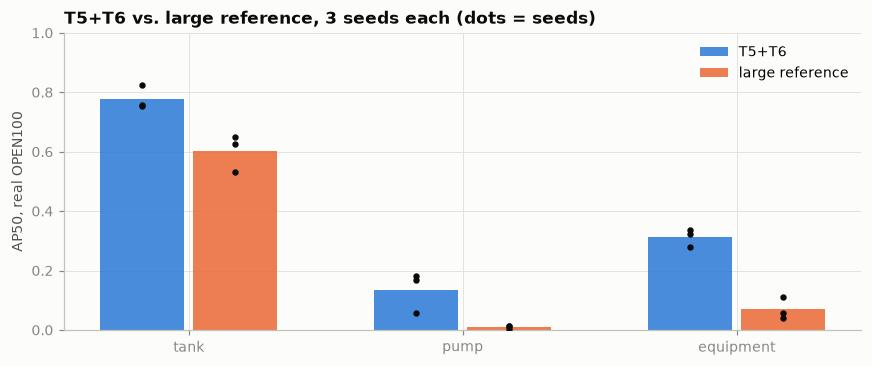

In [4]:
# AP50 per class: dots = individual seeds, bar = mean
fig, ax = plt.subplots(figsize=(8, 3.4))
groups = [("T5+T6", SERIES[0]), ("large reference", SERIES[1])]
w = 0.34
for gi, (model, col) in enumerate(groups):
    for ci, c in enumerate(CLS3):
        vals = [t["per_class_AP50"][c] for t in three[model]]
        x = ci + (gi - 0.5) * w
        ax.bar(x, np.mean(vals), width=w * 0.9, color=col, alpha=0.85, label=model if ci == 0 else None)
        ax.scatter([x] * 3, vals, color=INK, s=10, zorder=3)
ax.set_xticks(range(3)); ax.set_xticklabels(CLS3)
ax.set_ylabel("AP50, real OPEN100"); ax.set_ylim(0, 1)
ax.set_title("T5+T6 vs. large reference, 3 seeds each (dots = seeds)")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

**What the 3 seeds say** (all numbers: real OPEN100, 12 sheets, score ≥ 0.5 for the counts):
- **`tank` is the clear win:** AP50 **0.78** (0.75–0.82) for T5+T6 against **0.60** (0.53–0.65) for the large reference. The ranges do not overlap, so this is not seed luck. Tanks found: 29 / 29 / 29 of 35, against 27 / 26 / 24.
- **`equipment`: 0.31** (0.28–0.34) against 0.07 for the large reference; found 22–26 of 31 against 9–11. It also raises many false alarms (121–140 per run), so precision is low. Treat `equipment` boxes as candidates for review.
- **`pump` is not solved: 0.14** (0.06–0.18). One seed finds 2 of 16 pumps, the other two find none. On real sheets pumps are mostly small circles that look like instruments. Do not rely on the pump class yet.
- **mAP50 0.41** (0.40–0.42) against 0.22 for the large reference. The baseline's 0.39 is over 5 classes including the easy `instrument` (0.97) and `valve` (0.63), so it is not a fair comparison; on the shared classes the baseline is far behind on `tank` (0.26).
- Seed spread is small for `tank` and `mAP50`, larger for `equipment` and `pump`. Three seeds on 12 sheets is enough to separate T5+T6 from the reference, not to rank small differences.

## 1. Run summary

In [5]:
summary = {
    "model": "Faster R-CNN, ResNet-50 FPN v2 (COCO-pretrained, fine-tuned)",
    "input size": f"long side {ckpt_meta['max_side']} px",
    "classes": ", ".join(CLASSES),
    "training data": "PID2Graph synthetic sheets (PID2Graph Synthetic + Dataset PID), 635 train / 115 val",
    "test data": "12 real OPEN100 sheets (never seen in training)",
    "hardware": "NRP, 1x NVIDIA RTX 4090, mixed precision, batch 2",
    "epochs": f"{len(history)} ({history.minutes.sum():.1f} min of training)",
    "best epoch (by val mAP@.5)": ckpt_meta["epoch"],
    "peak GPU memory": f"{history.peak_gpu_GB.max():.1f} GB",
}
pd.Series(summary, name="").to_frame()

,
model,"Faster R-CNN, ResNet-50 FPN v2 (COCO-pretraine..."
input size,long side 2048 px
classes,"general, instrument, pump, tank, valve"
training data,PID2Graph synthetic sheets (PID2Graph Syntheti...
test data,12 real OPEN100 sheets (never seen in training)
hardware,"NRP, 1x NVIDIA RTX 4090, mixed precision, batch 2"
epochs,12 (12.6 min of training)
best epoch (by val mAP@.5),10
peak GPU memory,9.1 GB


## 2. Headline: synthetic vs. real

The model does very well on held-out *synthetic* sheets and much worse on *real* drawings. This synthetic-to-real gap is the main result.

In [6]:
headline = pd.DataFrame({
    "synthetic val (115 sheets)": [metrics["val"]["mAP50"], metrics["val"]["mAP"]],
    "real OPEN100 (12 sheets)": [metrics["test_open100_real"]["mAP50"], metrics["test_open100_real"]["mAP"]],
}, index=["mAP @ IoU .5", "mAP @ IoU .5:.95"])
headline.style.format("{:.2f}")

,synthetic val (115 sheets),real OPEN100 (12 sheets)
mAP @ IoU .5,0.96,0.39
mAP @ IoU .5:.95,0.88,0.28


## 3. Per-class accuracy

AP (averaged over IoU .5–.95) per class, synthetic vs. real. `instrument` holds up on real sheets. `tank`, `pump` and `general` collapse.

,synthetic val,real OPEN100
general,0.791,0.039
valve,0.792,0.406
instrument,0.894,0.802
pump,0.941,0.016
tank,0.974,0.123


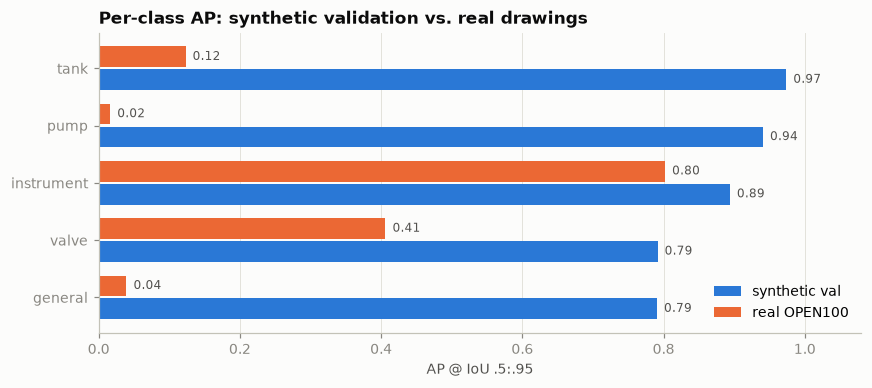

In [7]:
per_class = pd.DataFrame({
    "synthetic val": metrics["val"]["per_class_AP"],
    "real OPEN100": metrics["test_open100_real"]["per_class_AP"],
}).loc[CLASSES].sort_values("synthetic val")

fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(per_class))
h = 0.36
for k, (col, color) in enumerate([("synthetic val", SERIES[0]), ("real OPEN100", SERIES[1])]):
    bars = ax.barh(y + (k - 0.5) * (h + 0.04), per_class[col], height=h, color=color, label=col)
    for b, v in zip(bars, per_class[col]):
        ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f"{v:.2f}", va="center", fontsize=8, color=INK_2)
ax.set_yticks(y, per_class.index)
ax.set_xlim(0, 1.08)
ax.set_xlabel("AP @ IoU .5:.95")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_title("Per-class AP: synthetic validation vs. real drawings")
plt.tight_layout()
per_class.round(3)

## 4. Training curves

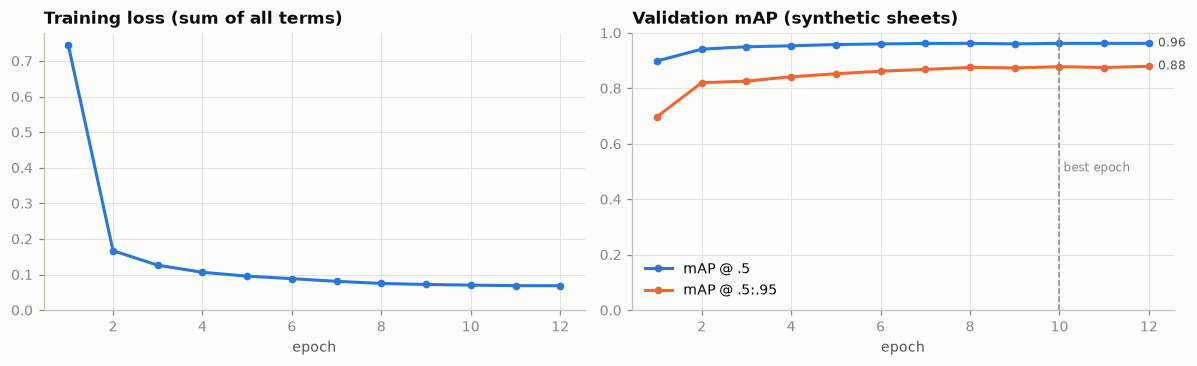

In [8]:
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.4))
a.plot(history.epoch, history.loss, color=SERIES[0], lw=2, marker="o", ms=4)
a.set_title("Training loss (sum of all terms)")
a.set_xlabel("epoch")
a.set_ylim(0, None)

b.plot(history.epoch, history.val_mAP50, color=SERIES[0], lw=2, marker="o", ms=4, label="mAP @ .5")
b.plot(history.epoch, history.val_mAP, color=SERIES[1], lw=2, marker="o", ms=4, label="mAP @ .5:.95")
for col in ["val_mAP50", "val_mAP"]:
    b.annotate(f"{history[col].iloc[-1]:.2f}", (history.epoch.iloc[-1], history[col].iloc[-1]),
               xytext=(6, 0), textcoords="offset points", va="center", fontsize=8, color=INK_2)
b.axvline(ckpt_meta["epoch"], color=MUTED, lw=1, ls="--")
b.text(ckpt_meta["epoch"], 0.5, " best epoch", color=MUTED, fontsize=8)
b.set_title("Validation mAP (synthetic sheets)")
b.set_xlabel("epoch")
b.set_ylim(0, 1)
b.legend(loc="lower left")
plt.tight_layout()

Validation mAP levels off after about 6 epochs. More epochs on the same synthetic data won't close the gap to real sheets.

## 5. Real sheets at the default threshold

mAP averages over all confidence thresholds. In practice you use one threshold (0.5, the one `predict()` uses), so this section counts per class, on the 12 real sheets:
- **found**: ground-truth boxes matched by a prediction of the same class (IoU ≥ 0.5)
- **missed**: ground-truth boxes with no matching prediction
- **false alarms**: predictions that match no ground-truth box of their class

Ground truth comes from the OPEN100 `.graphml` files. Predictions come from the CSVs the NRP job saved, in original-image pixels.

In [9]:
def load_gt(k: int) -> pd.DataFrame:
    rows = []
    W, H = Image.open(OPEN100 / f"{k}.png").size  # header only; the equipment size rule is relative to the sheet
    for _, d in nx.read_graphml(OPEN100 / f"{k}.graphml").nodes(data=True):
        x0, x1 = sorted((float(d["xmin"]), float(d["xmax"])))
        y0, y1 = sorted((float(d["ymin"]), float(d["ymax"])))
        cls = nrp_train.map_label(d["label"], "PID2Graph OPEN100", x1 - x0, y1 - y0, W, H,
                                  RUN_CFG["class_map"], RUN_CFG["equipment_min_px"] or 0)
        if cls:
            rows.append({"cls": cls, "xmin": x0, "ymin": y0, "xmax": x1, "ymax": y1})
    return pd.DataFrame(rows, columns=["cls", "xmin", "ymin", "xmax", "ymax"])


def load_pred(k: int) -> pd.DataFrame:
    return pd.read_csv(RUN / "predictions" / f"PID2Graph_OPEN100_{k}.csv")


def iou_matrix(a: pd.DataFrame, b: pd.DataFrame) -> np.ndarray:
    A, B = a[["xmin", "ymin", "xmax", "ymax"]].to_numpy(), b[["xmin", "ymin", "xmax", "ymax"]].to_numpy()
    if len(A) == 0 or len(B) == 0:
        return np.zeros((len(A), len(B)))
    ix0, iy0 = np.maximum(A[:, None, 0], B[None, :, 0]), np.maximum(A[:, None, 1], B[None, :, 1])
    ix1, iy1 = np.minimum(A[:, None, 2], B[None, :, 2]), np.minimum(A[:, None, 3], B[None, :, 3])
    inter = np.clip(ix1 - ix0, 0, None) * np.clip(iy1 - iy0, 0, None)
    area = lambda X: (X[:, 2] - X[:, 0]) * (X[:, 3] - X[:, 1])
    return inter / (area(A)[:, None] + area(B)[None, :] - inter)


def greedy_match(gt, pred, thr=0.5, same_class=True):
    """Match predictions (highest score first) to unmatched GT boxes. Returns [(gt_idx, pred_idx)]."""
    iou = iou_matrix(gt, pred)
    if same_class and len(gt) and len(pred):
        iou = iou * (gt.cls.to_numpy()[:, None] == pred.cls.to_numpy()[None, :])
    used, pairs = set(), []
    for j in np.argsort(-pred.score.to_numpy()) if len(pred) else []:
        cand = [(iou[i, j], i) for i in range(len(gt)) if i not in used and iou[i, j] >= thr]
        if cand:
            i = max(cand)[1]
            used.add(i)
            pairs.append((i, j))
    return pairs


rows = []
for k in range(12):
    gt, pred = load_gt(k), load_pred(k)
    pairs = greedy_match(gt, pred)
    tp_gt = {i for i, _ in pairs}
    tp_pred = {j for _, j in pairs}
    for c in CLASSES:
        rows.append({
            "sheet": k, "cls": c,
            "found": sum(1 for i in tp_gt if gt.cls.iloc[i] == c),
            "missed": int(((gt.cls == c).to_numpy() & ~np.isin(np.arange(len(gt)), list(tp_gt))).sum()) if len(gt) else 0,
            "false alarms": int(((pred.cls == c).to_numpy() & ~np.isin(np.arange(len(pred)), list(tp_pred))).sum()) if len(pred) else 0,
        })
per_sheet = pd.DataFrame(rows)
pr = per_sheet.groupby("cls")[["found", "missed", "false alarms"]].sum().loc[CLASSES]
pr["recall"] = pr.found / (pr.found + pr.missed)
pr["precision"] = pr.found / (pr.found + pr["false alarms"])
pr.loc["all"] = pr[["found", "missed", "false alarms"]].sum()
pr.loc["all", "recall"] = pr.loc["all", "found"] / (pr.loc["all", "found"] + pr.loc["all", "missed"])
pr.loc["all", "precision"] = pr.loc["all", "found"] / (pr.loc["all", "found"] + pr.loc["all", "false alarms"])
pr.style.format({"found": "{:.0f}", "missed": "{:.0f}", "false alarms": "{:.0f}", "recall": "{:.0%}", "precision": "{:.0%}"},
                na_rep="– (none predicted)")

,found,missed,false alarms,recall,precision
cls,,,,,
general,45,189,207,19%,18%
instrument,346,4,39,99%,90%
pump,0,16,0,0%,– (none predicted)
tank,10,25,26,29%,28%
valve,178,79,170,69%,51%
all,579,313,442,65%,57%


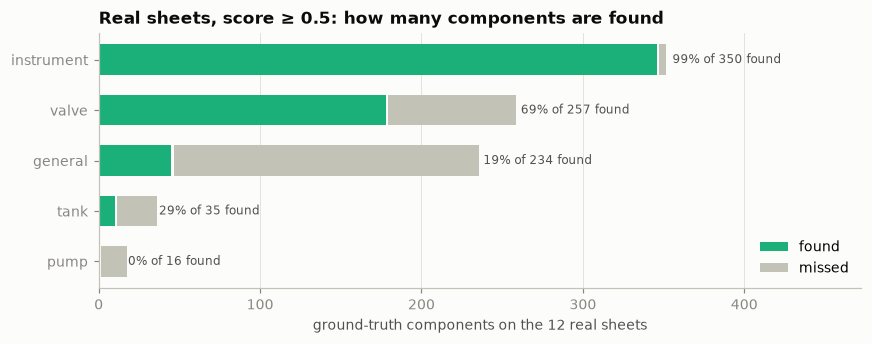

In [10]:
# where do the ground-truth components go? found vs. missed, per class
p = pr.loc[CLASSES].sort_values("found")
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(p.index, p.found, color=SERIES[2], label="found", height=0.6)
ax.barh(p.index, p.missed, left=p.found + p[["found", "missed"]].sum(axis=1).max() * 0.004,
        color="#c3c2b7", label="missed", height=0.6)
for i, (c, r) in enumerate(p.iterrows()):
    total = r.found + r.missed
    ax.text(total * 1.01 + 2, i, f"{r.recall:.0%} of {total:.0f} found", va="center", fontsize=8, color=INK_2)
ax.set_xlim(0, p[["found", "missed"]].sum(axis=1).max() * 1.35)
ax.set_xlabel("ground-truth components on the 12 real sheets")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_title("Real sheets, score ≥ 0.5: how many components are found")
plt.tight_layout()

At the working threshold, **instruments are nearly solved on real sheets: 99% found, 90% precision.** Valves are usable (69% found) but noisy. `general`, `tank` and `pump` are where the work is.

## 6. Which classes get confused with which

Here boxes are matched **regardless of class** (IoU ≥ 0.5), so a tank predicted as `general` counts as *confused*, not missed.
- Rows: the true class.
- Columns: what the model said. *missed* means no box at all.
- The last row counts predictions that matched nothing (*false alarm*).

,general,instrument,pump,tank,valve,missed
general,45,5,0,1,8,175
instrument,0,345,0,2,0,3
pump,2,6,0,4,0,4
tank,2,0,0,10,0,23
valve,9,2,0,0,178,68
false alarm,194,27,0,19,162,0


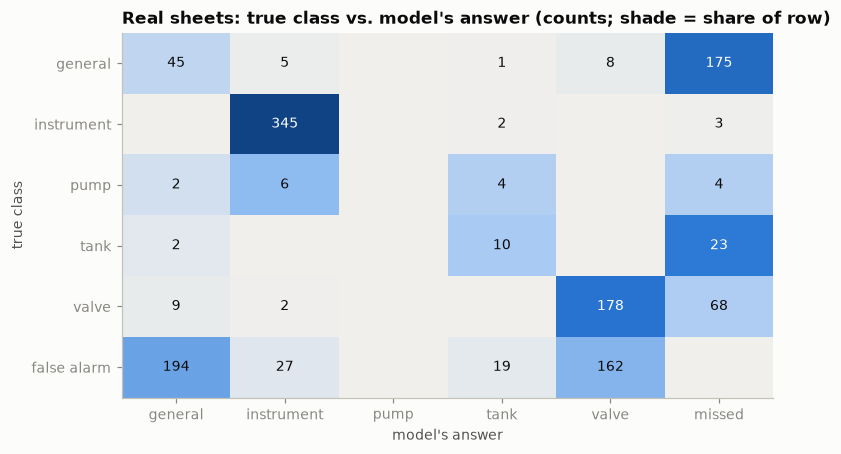

In [11]:
labels = CLASSES + ["missed"]
conf = pd.DataFrame(0, index=CLASSES + ["false alarm"], columns=labels)
for k in range(12):
    gt, pred = load_gt(k), load_pred(k)
    pairs = greedy_match(gt, pred, same_class=False)
    for i, j in pairs:
        conf.loc[gt.cls.iloc[i], pred.cls.iloc[j]] += 1
    for i in set(range(len(gt))) - {i for i, _ in pairs}:
        conf.loc[gt.cls.iloc[i], "missed"] += 1
    for j in set(range(len(pred))) - {j for _, j in pairs}:
        conf.loc["false alarm", pred.cls.iloc[j]] += 1

# row-normalised shading (share of each true class); cell text shows counts
share = conf.div(conf.sum(axis=1).replace(0, 1), axis=0)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.imshow(share.to_numpy(), cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "seq", ["#f0efec", "#9ec5f4", "#2a78d6", "#104281"]), vmin=0, vmax=1, aspect="auto")
for (r, c), v in np.ndenumerate(conf.to_numpy()):
    if v:
        ax.text(c, r, str(v), ha="center", va="center", fontsize=9,
                color="white" if share.iloc[r, c] > 0.55 else INK)
ax.set_xticks(range(len(labels)), labels, rotation=0)
ax.set_yticks(range(len(conf.index)), conf.index)
ax.set_xlabel("model's answer")
ax.set_ylabel("true class")
ax.grid(False)
ax.set_title("Real sheets: true class vs. model's answer (counts; shade = share of row)")
plt.tight_layout()
conf

**What the matrix shows:**
- **No real pump is ever called a pump.** Of 16 pumps, 6 come out as `instrument`: on these sheets pumps are drawn as circles, like instrument bubbles. Another 4 come out as `tank`, 2 as `general`, and 4 are missed.
- **Most tanks and `general` equipment are simply missed**, not confused with other classes. The model doesn't recognise the real drawing style at all.
- **False alarms are mostly `general` and `valve`.** Section 8 shows where they come from:
  - off-page connector arrows, predicted as `general`;
  - the numbered grid markers in the sheet margin;
  - annotation granularity: e.g. the ground truth puts **one** box around a 12-fan air-cooled condenser, while the model boxes each fan. Some of these "false alarms" are defensible.

## 7. Your drawing: `pid_big.png`

In [12]:
user_det = pd.read_csv(RUN / "predictions" / "pid_big_pred.csv")
counts = user_det.cls.value_counts().reindex(CLASSES, fill_value=0)
print(f"{len(user_det)} components detected at score >= 0.5:", counts.to_dict())
print(f"median confidence: {user_det.score.median():.2f}; below 0.7: {(user_det.score < 0.7).sum()}")

142 components detected at score >= 0.5: {'general': 30, 'instrument': 46, 'pump': 0, 'tank': 0, 'valve': 66}
median confidence: 0.95; below 0.7: 24


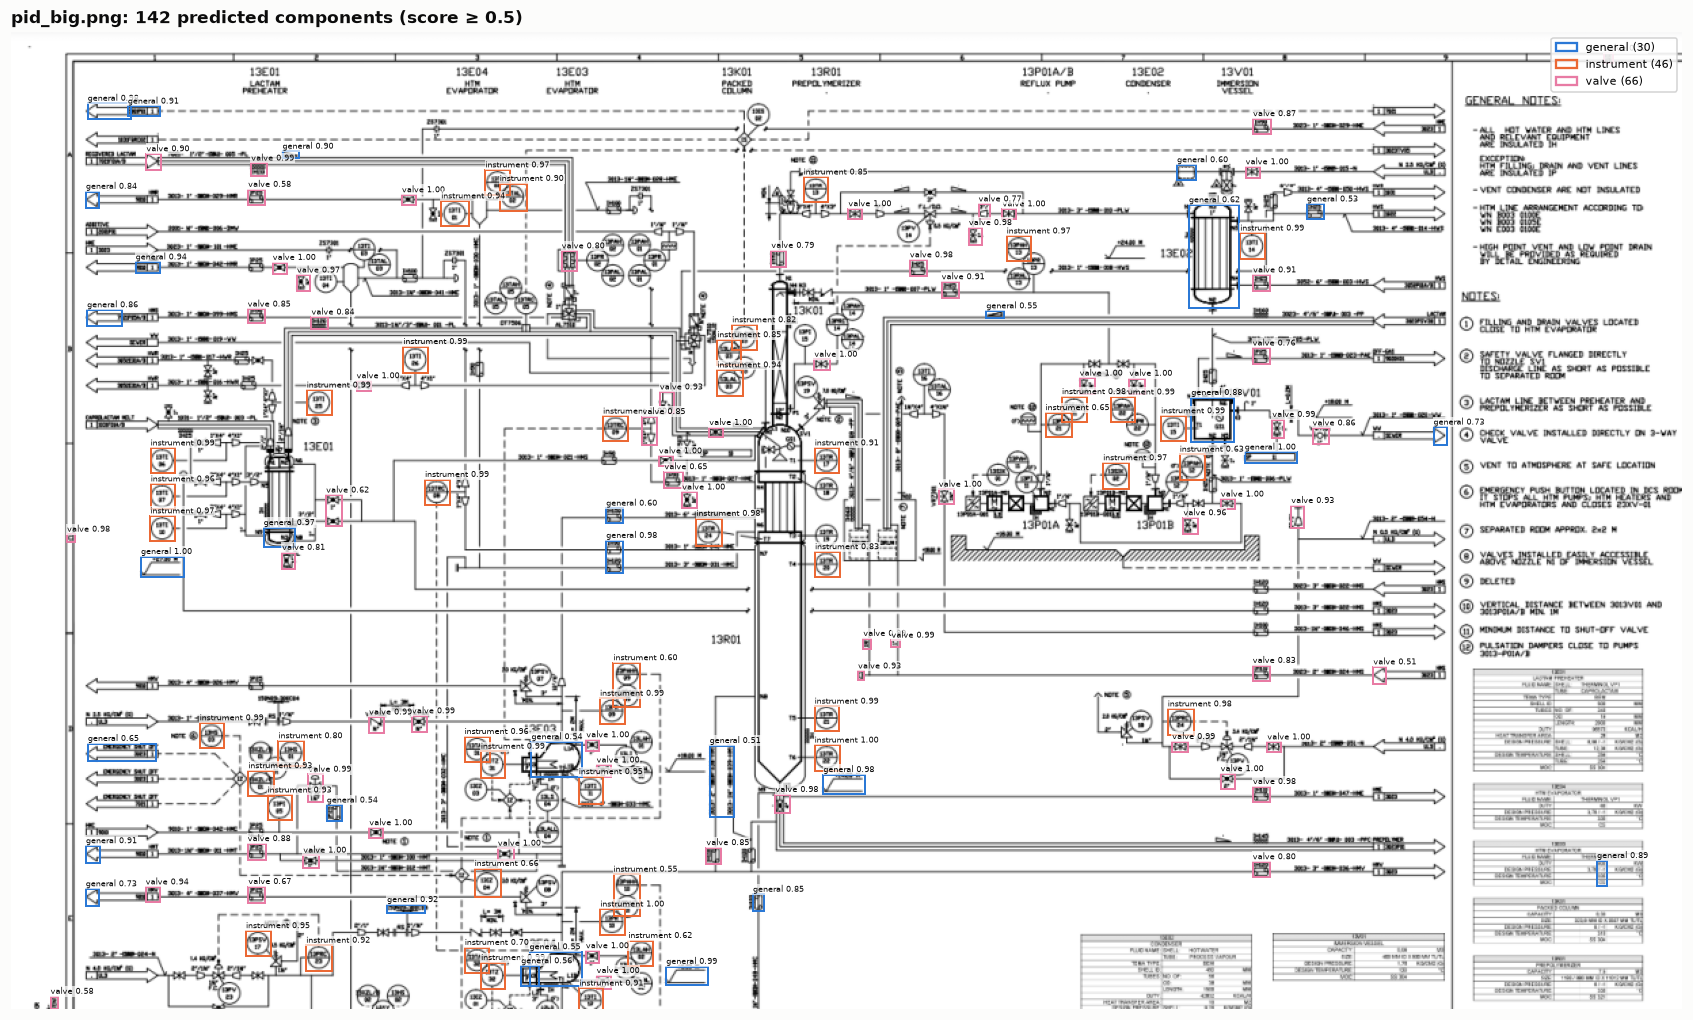

In [13]:
def draw(ax, img, boxes: pd.DataFrame, scale: float, title: str, show_scores: bool = False):
    ax.imshow(img, cmap="gray")
    for r in boxes.itertuples():
        c = COLOR[r.cls]
        ax.add_patch(mpatches.Rectangle((r.xmin * scale, r.ymin * scale), (r.xmax - r.xmin) * scale,
                                        (r.ymax - r.ymin) * scale, fill=False, lw=1.3, ec=c))
        if show_scores:
            ax.text(r.xmin * scale, r.ymin * scale - 2, f"{r.cls} {r.score:.2f}", fontsize=5.5, color=INK,
                    bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.7))
    present = [c for c in CLASSES if c in set(boxes.cls)]
    ax.legend(handles=[mpatches.Patch(fc="none", ec=COLOR[c], lw=1.5, label=f"{c} ({(boxes.cls == c).sum()})") for c in present],
              loc="upper right", fontsize=7, frameon=True, facecolor="white", framealpha=0.85)
    ax.set_title(title)
    ax.axis("off")


img = Image.open(USER_IMAGE).convert("L")
fig, ax = plt.subplots(figsize=(16, 16 * img.height / img.width))
draw(ax, img, user_det, 1.0, f"pid_big.png: {len(user_det)} predicted components (score ≥ 0.5)", show_scores=True)
plt.tight_layout()

**Reading this drawing:**
- **Instrument bubbles:** mostly found with high confidence. A few clusters near the evaporators have no boxes.
- **Valves:** found along most lines.
- **Equipment:** the condenser *13E02* and immersion vessel *13V01* are boxed as `general`. The tall column/reactor *13K01 / 13R01*, the reflux pumps *13P01A/B* and most of the preheater *13E01* are **not** detected. No `tank` or `pump` predictions at all, which matches the near-zero real-sheet AP for those classes above.
- **False alarms:** the off-page connector arrows on the left edge come out as `general`. That class (`inlet/outlet`) was dropped from training, so the model has no proper label for them. There's also a box inside the data tables on the right.
- **Image quality:** the file is a 1232×720 screenshot, upscaled to 2048 px for the model, so small symbols are blurry.

In [14]:
# the most confident detections on your drawing (coordinates in original-image pixels)
user_det.sort_values("score", ascending=False).round(1).head(15)

,cls,score,xmin,ymin,xmax,ymax
0,valve,1.0,891.2,546.2,901.5,557.3
1,valve,1.0,423.6,521.2,433.1,529.6
2,valve,1.0,263.6,586.0,273.8,593.6
3,valve,1.0,287.7,119.4,298.1,126.8
4,general,1.0,909.0,309.1,947.5,316.8
5,valve,1.0,254.3,256.5,265.1,263.9
6,valve,1.0,925.6,522.8,936.0,530.0
7,valve,1.0,591.7,240.7,603.1,248.2
8,valve,1.0,616.8,129.7,627.2,137.4
9,valve,1.0,823.9,254.7,835.3,266.2


## 8. Real sheets: ground truth vs. prediction

Left: ground truth. Right: prediction at score ≥ 0.5. The three sheets shown have the best, median and worst recall. Call `compare(k)` for any sheet `k` from 0 to 11.

In [15]:
def compare(k: int, max_side: int = 1800):
    gt, pred = load_gt(k), load_pred(k)
    img = Image.open(OPEN100 / f"{k}.png").convert("L")
    s = min(1.0, max_side / max(img.size))
    img = img.resize((round(img.width * s), round(img.height * s)))
    fig, (a, b) = plt.subplots(1, 2, figsize=(18, 18 * img.height / img.width / 2 + 0.6))
    draw(a, img, gt.assign(score=1.0), s, f"OPEN100/{k}: ground truth ({len(gt)})")
    draw(b, img, pred, s, f"OPEN100/{k}: prediction ({len(pred)})")
    plt.tight_layout()


recall_by_sheet = per_sheet.groupby("sheet")[["found", "missed"]].sum()
recall_by_sheet["recall"] = recall_by_sheet.found / (recall_by_sheet.found + recall_by_sheet.missed)
order = recall_by_sheet.recall.sort_values()
picks = {"best": order.index[-1], "median": order.index[len(order) // 2], "worst": order.index[0]}
print({k: f"sheet {v} (recall {recall_by_sheet.recall[v]:.0%})" for k, v in picks.items()})
recall_by_sheet.style.format({"recall": "{:.0%}"})

{'best': 'sheet 9 (recall 80%)', 'median': 'sheet 11 (recall 71%)', 'worst': 'sheet 1 (recall 37%)'}


,found,missed,recall
sheet,,,
0,71,22,76%
1,13,22,37%
2,52,39,57%
3,46,24,66%
4,56,33,63%
5,42,32,57%
6,59,22,73%
7,49,14,78%
8,21,8,72%


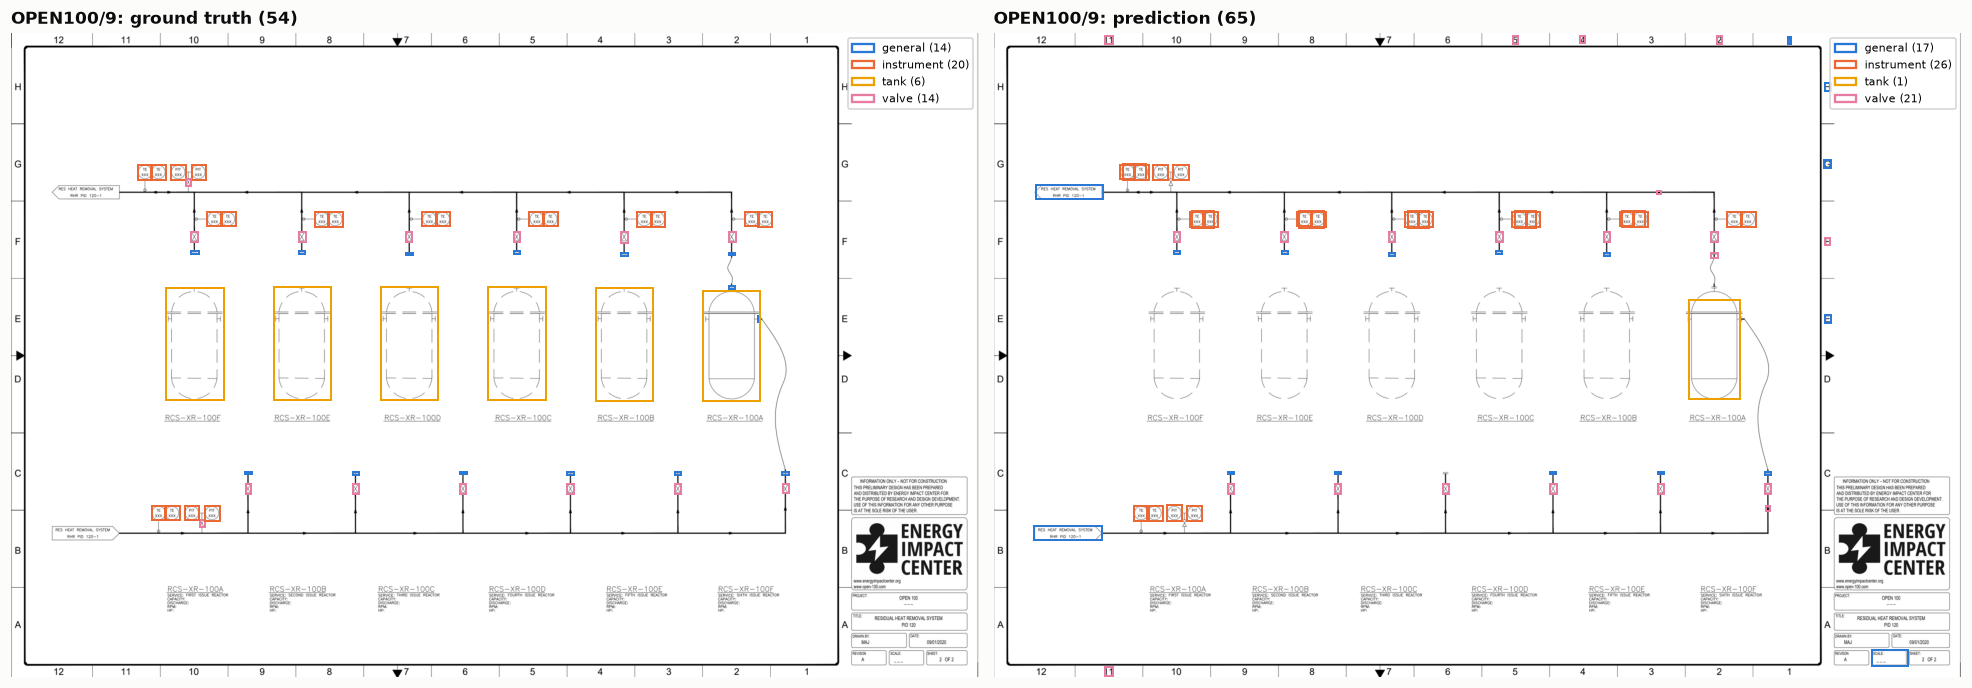

In [16]:
compare(picks['best'])

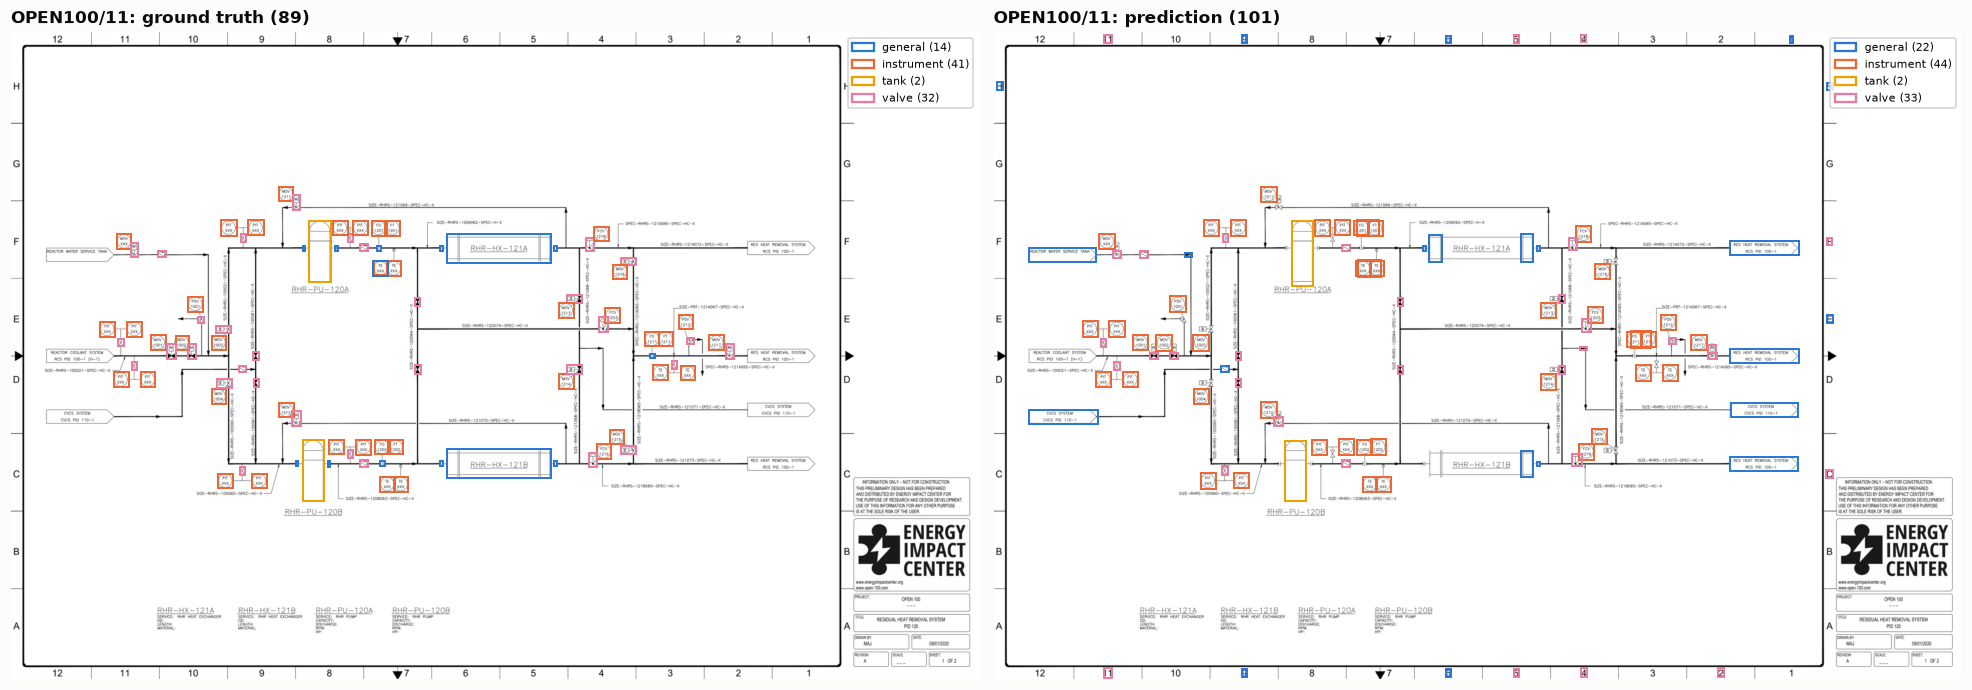

In [17]:
compare(picks['median'])

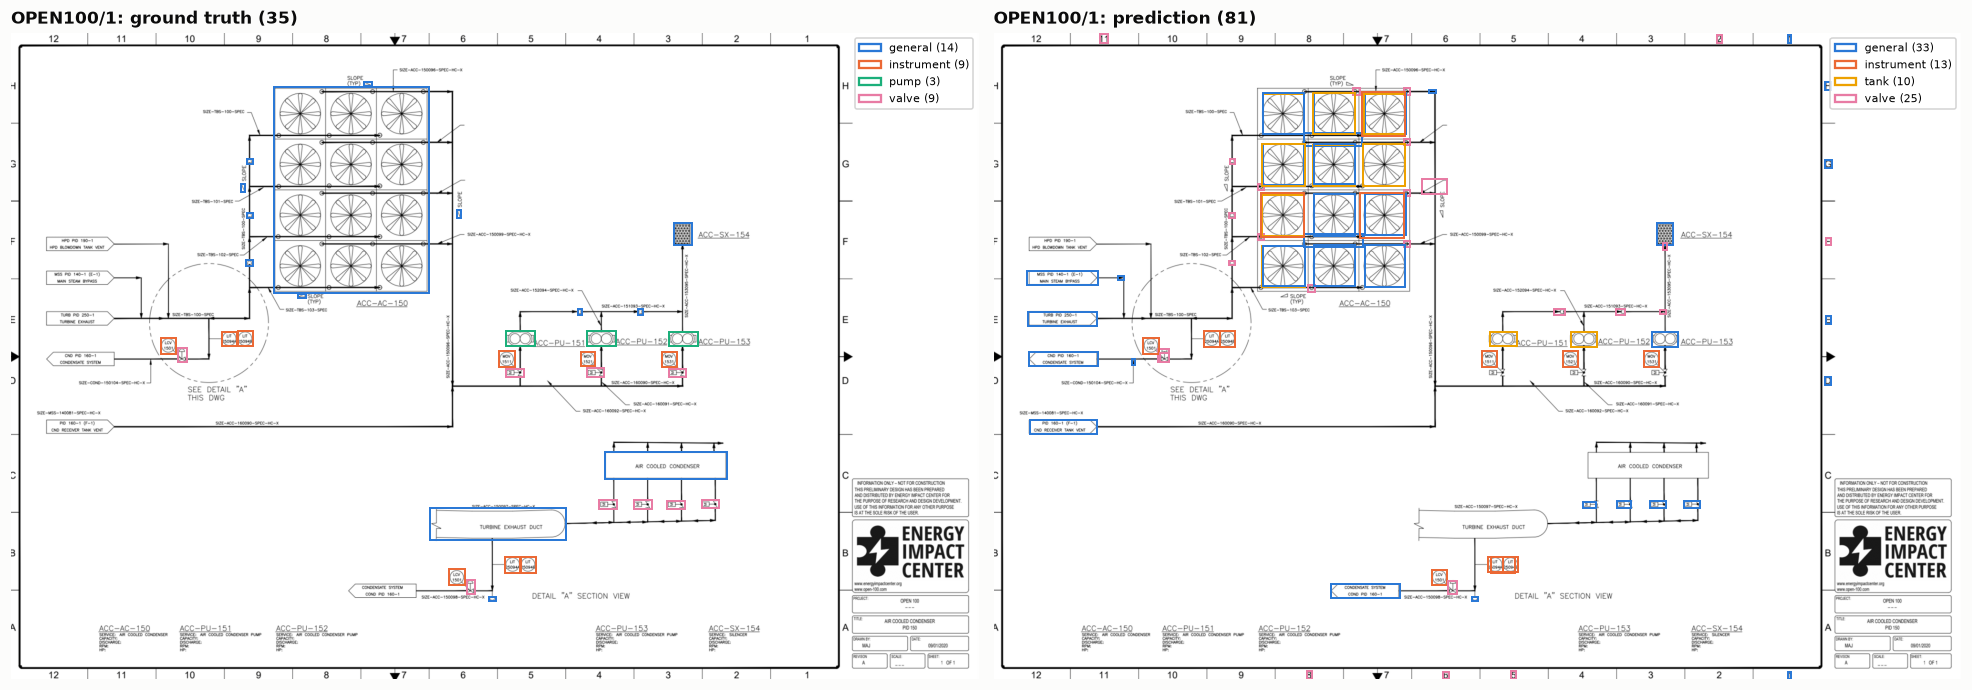

In [18]:
compare(picks['worst'])

## 9. Findings and next steps

**What works**
- The pipeline end to end: PID2Graph, then training on NRP (20 min on an RTX 4090), then boxes drawn on any P&ID image.
- **Instrument bubbles transfer to real drawings:** 99% found at 90% precision on OPEN100, AP 0.80. Valves partly do: 69% found, 51% precision.

**What doesn't**
- **Large equipment on real drawings.** The tank and pump classes (AP 0.12 / 0.02 on real sheets) were learned from a single synthetic symbol set. The model learned *that drawing style*, not what a tank or pump is. On your drawing, the column/reactor and pumps are missed entirely.
- **`general` is too broad.** Heat exchangers, filters, nozzles and more share one label, and real-sheet AP is 0.04.
- **Pumps drawn as circles are read as instruments.** No real pump was ever labelled `pump`.
- **False alarms:** off-page connectors (a class we dropped), margin grid markers, and multi-part equipment boxed piece by piece.

**Next steps, most impact first**
1. **Hand-label 20–50 real P&IDs**, ideally in the style you care about, fine-tune on them, and keep some for testing. Label columns, vessels, pumps, heat exchangers and compressors as separate classes. The model has never seen a real column.
2. **Make synthetic training sheets look more realistic:** vary line weight, add blur, JPEG/scan noise, text clutter and random tables.
3. **Bring back `inlet/outlet`** as a class, consider splitting `general`, and mask the sheet border and title block before detection (the preprocessing in `pid-line-detection` already does this).
4. **Use higher-resolution inputs** (the original PDF rather than screenshots), or tile large sheets so small symbols keep their detail.

## 10. Large model (T5+T6) on 5 outside drawings

This section uses the **large model** (T5+T6, checkpoint `runs/scr-t5t6-s0/best.pt`, seed 0), not the baseline from sections 1–9. It detects three classes: `tank`, `pump` and `equipment` (everything else large: columns, reactors, exchangers, dryers, ...).

It was run on 5 drawings that are not in any training set: `pid_big.png` (section 7's drawing) and the 4 images in `PID_test_pngs/`. Settings: score ≥ 0.5, input long side 2048 px, CPU. The predictions come from `draw_prediction()` in `nrp/train.py` and are read from `out/`.

**There is no ground truth for these drawings**, so there are no mAP numbers here. The verdicts below are visual judgements: I looked at each drawing and compared the boxes with the equipment I could see.

In [19]:
# saved predictions of the large model (T5+T6) on the 5 outside drawings; classes are fixed by that checkpoint
BIG_CLASSES = ["tank", "pump", "equipment"]
BIG_COLOR = {c: SERIES[i] for i, c in enumerate(BIG_CLASSES)}
OUT = ROOT / "out"
TEST_DIR = ROOT / "PID_test_pngs"
M311 = "M311cc9690c6c38baf4afbdc33be266ba1767697919997"
BIG_SHEETS = [  # (label, source image, prediction csv, annotated png, verdict)
    ("pid_big.png", USER_IMAGE, OUT / "pid_big_pred_t5t6.csv", OUT / "pid_big_pred_t5t6.png",
     "Poor: only condenser 13E02 found (as tank); 6 of 7 'equipment' boxes are data tables; column, reactor, vessel, pumps, exchangers missed"),
    (f"{M311[:4]}... (ethanol PFD)", TEST_DIR / f"{M311}.webp", OUT / "test_pngs" / f"{M311}_pred_t5t6.csv", OUT / "test_pngs" / f"{M311}_pred_t5t6.png",
     "Good: most major items found; distillation column missed, pump labelled equipment (0.53), fermentation unit double-boxed"),
    ("piping-diagram-2", TEST_DIR / "piping-diagram-2.png", OUT / "test_pngs" / "piping-diagram-2_pred_t5t6.csv", OUT / "test_pngs" / "piping-diagram-2_pred_t5t6.png",
     "Mixed: evaporator and knockout drum found (drum double-boxed); 7 instrument bubbles called tank; compressor missed"),
    ("process-flow-diagram-osha-small", TEST_DIR / "process-flow-diagram-osha-small.png", OUT / "test_pngs" / "process-flow-diagram-osha-small_pred_t5t6.csv", OUT / "test_pngs" / "process-flow-diagram-osha-small_pred_t5t6.png",
     "Mixed: reactor, stripper, wash vessel, receiver, condenser, drum found; 3 house-shaped storage tanks and exchanger missed"),
    ("processing-pid-rev", TEST_DIR / "processing-pid-rev.webp", OUT / "test_pngs" / "processing-pid-rev_pred_t5t6.csv", OUT / "test_pngs" / "processing-pid-rev_pred_t5t6.png",
     "Poor: only Tk-16 found; about 10 items missed (column, reactors, tanks, pumps, cooling tower)"),
]

rows = []
for name, src_img, csv, _, verdict in BIG_SHEETS:
    det = pd.read_csv(csv)
    assert (det.score >= 0.5).all(), name  # CSVs hold the score >= 0.5 detections only
    w, h = Image.open(src_img).size  # header only
    n = det.cls.value_counts().reindex(BIG_CLASSES, fill_value=0)
    rows.append({"image": name, "source size (px)": f"{w}×{h}", "tank": n["tank"], "equipment": n["equipment"],
                 "pump": n["pump"], "total": len(det), "verdict": verdict})
big_summary = pd.DataFrame(rows).set_index("image")
big_summary.style.set_properties(subset=["verdict"], **{"text-align": "left", "white-space": "normal", "min-width": "420px"})

,source size (px),tank,equipment,pump,total,verdict
image,,,,,,
pid_big.png,1232×720,1,7,0,8,"Poor: only condenser 13E02 found (as tank); 6 of 7 'equipment' boxes are data tables; column, reactor, vessel, pumps, exchangers missed"
M311... (ethanol PFD),2716×1616,8,7,0,15,"Good: most major items found; distillation column missed, pump labelled equipment (0.53), fermentation unit double-boxed"
piping-diagram-2,942×792,14,0,0,14,Mixed: evaporator and knockout drum found (drum double-boxed); 7 instrument bubbles called tank; compressor missed
process-flow-diagram-osha-small,241×312,5,1,0,6,"Mixed: reactor, stripper, wash vessel, receiver, condenser, drum found; 3 house-shaped storage tanks and exchanger missed"
processing-pid-rev,650×416,1,0,0,1,"Poor: only Tk-16 found; about 10 items missed (column, reactors, tanks, pumps, cooling tower)"


### Annotated predictions

Boxes are coloured by class (tank, pump, equipment); the label on each box is the class and score. The images are the saved outputs of `draw_prediction()`.

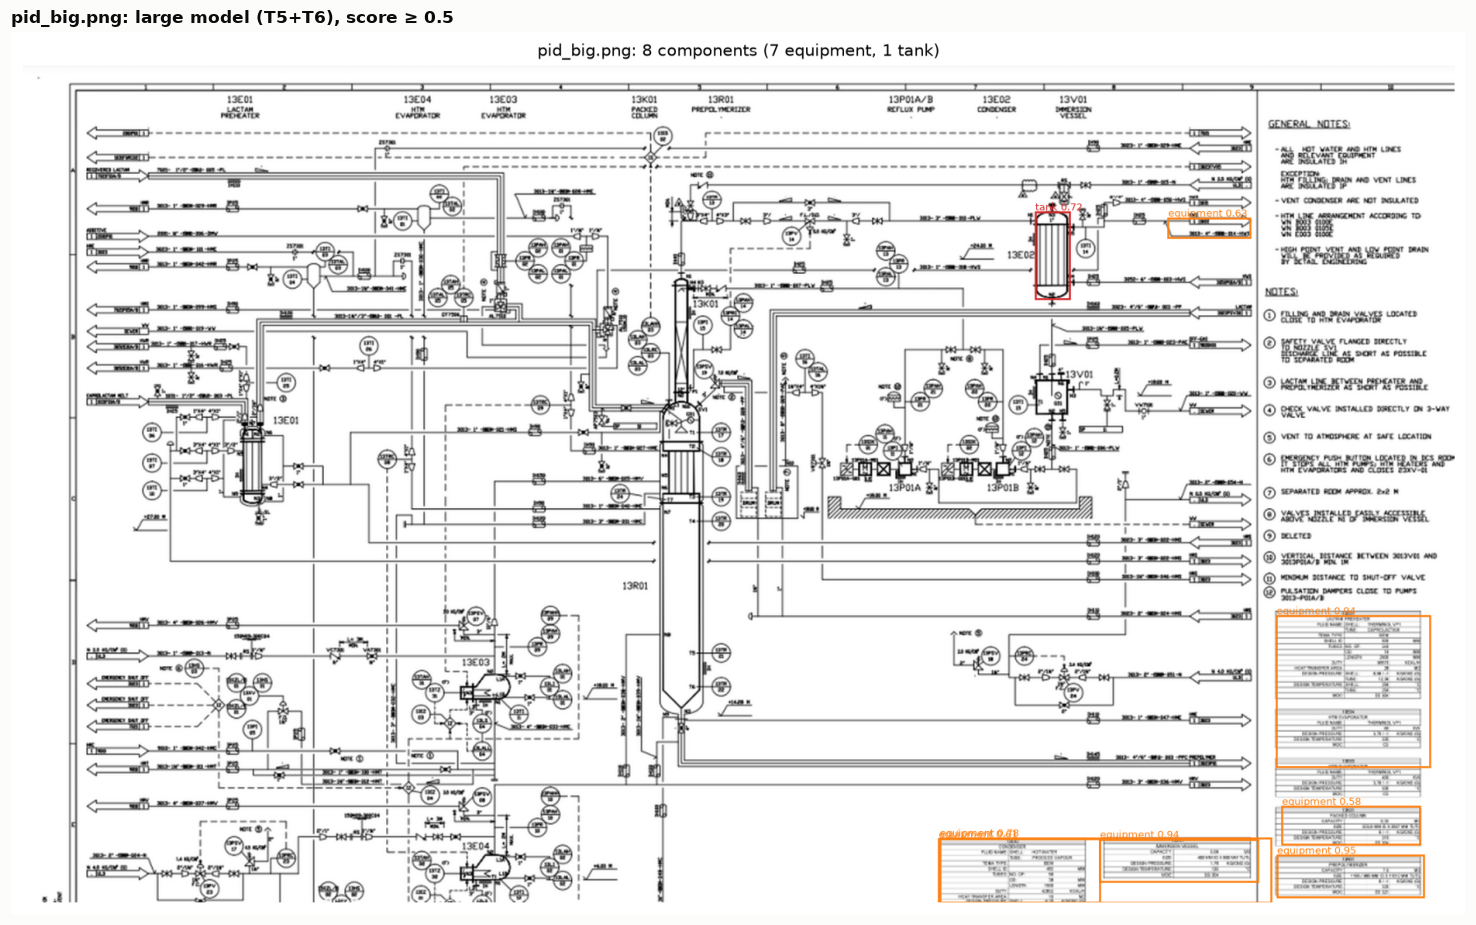

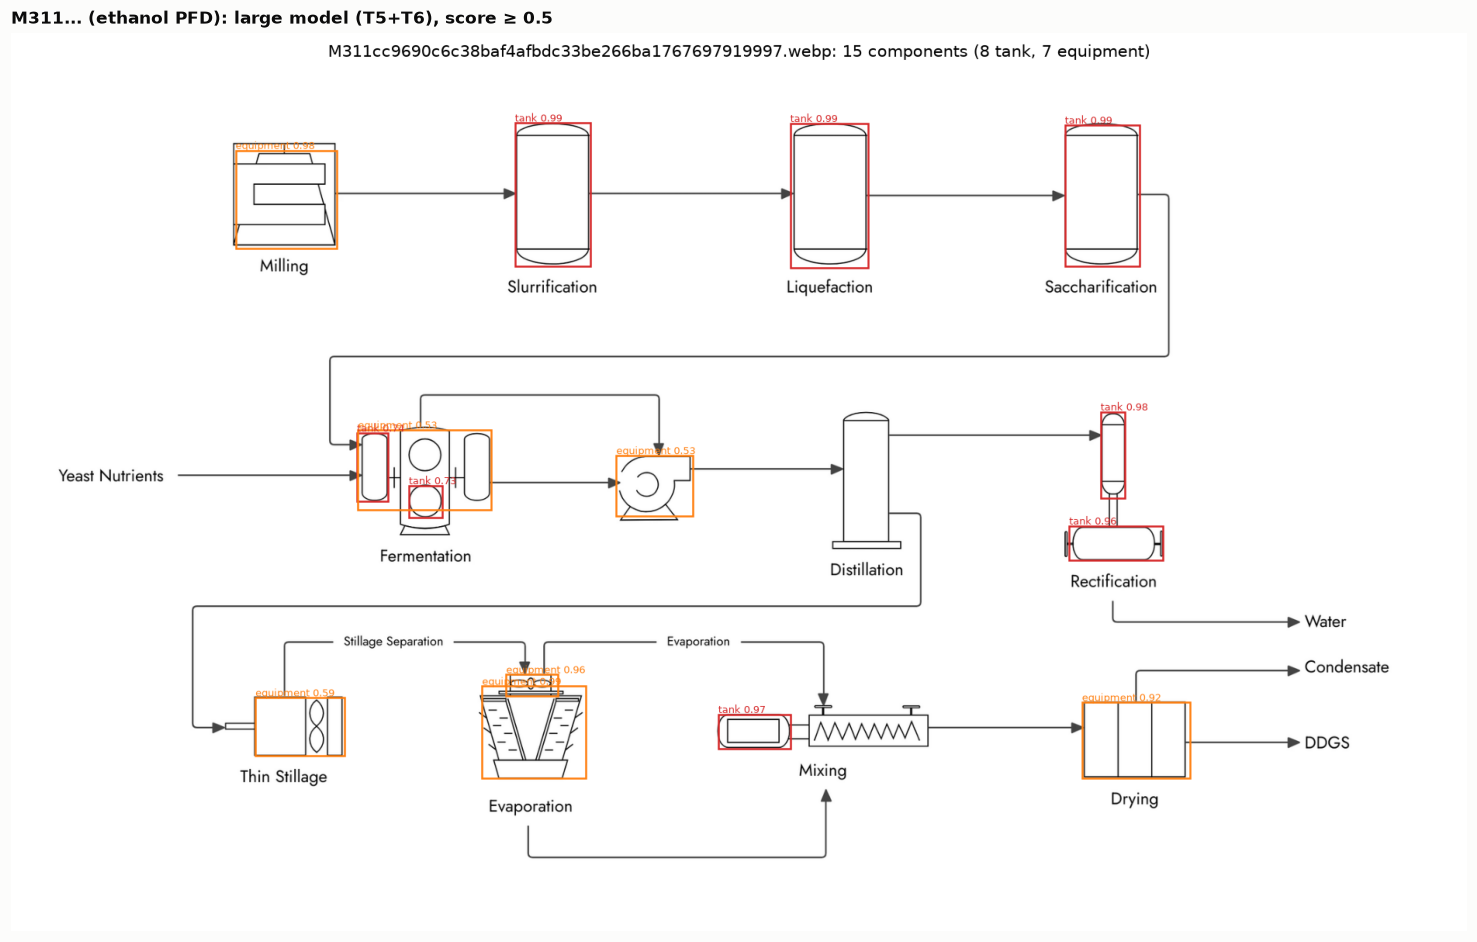

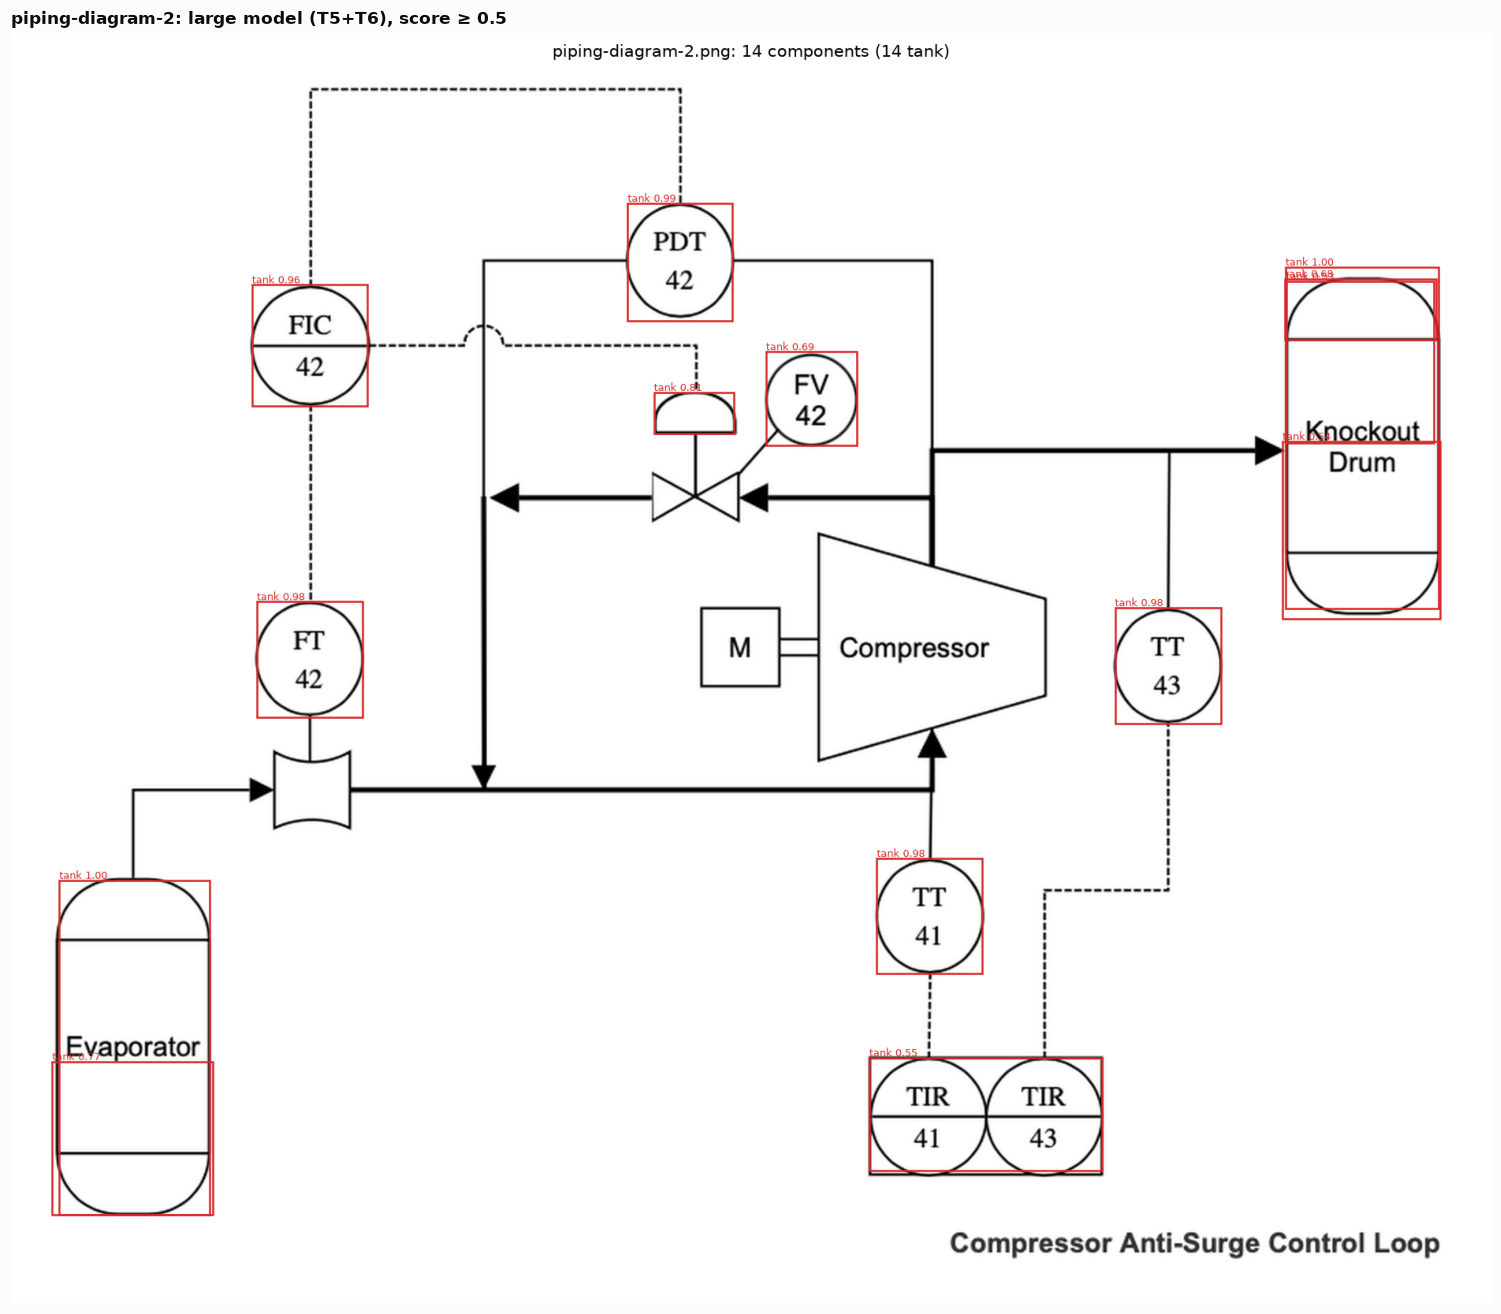

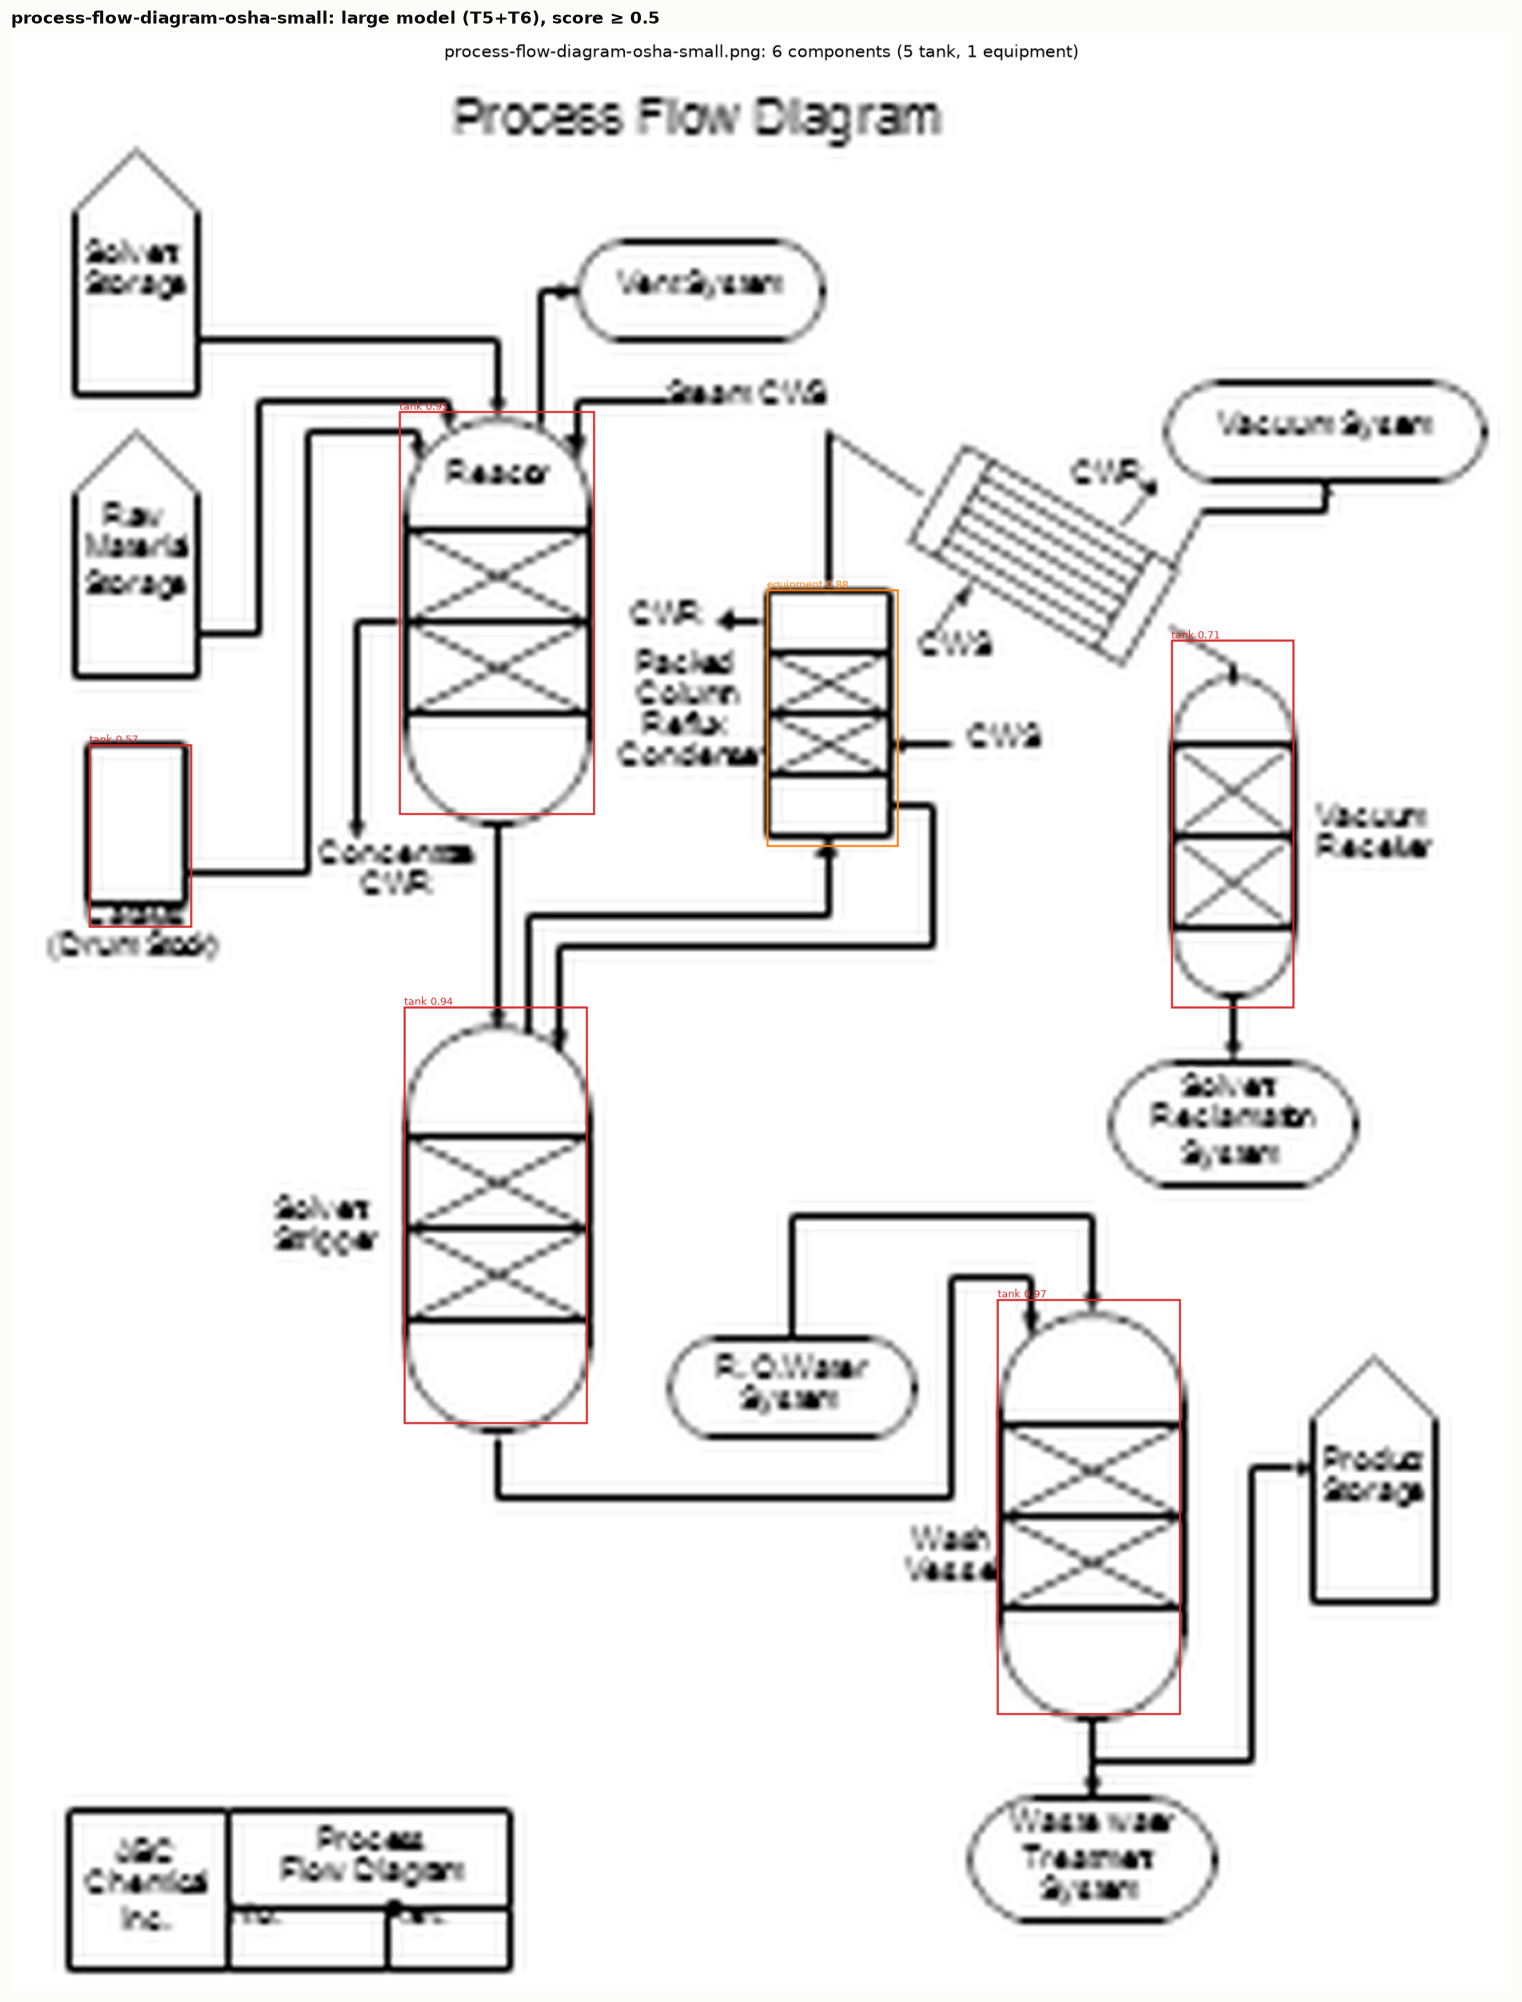

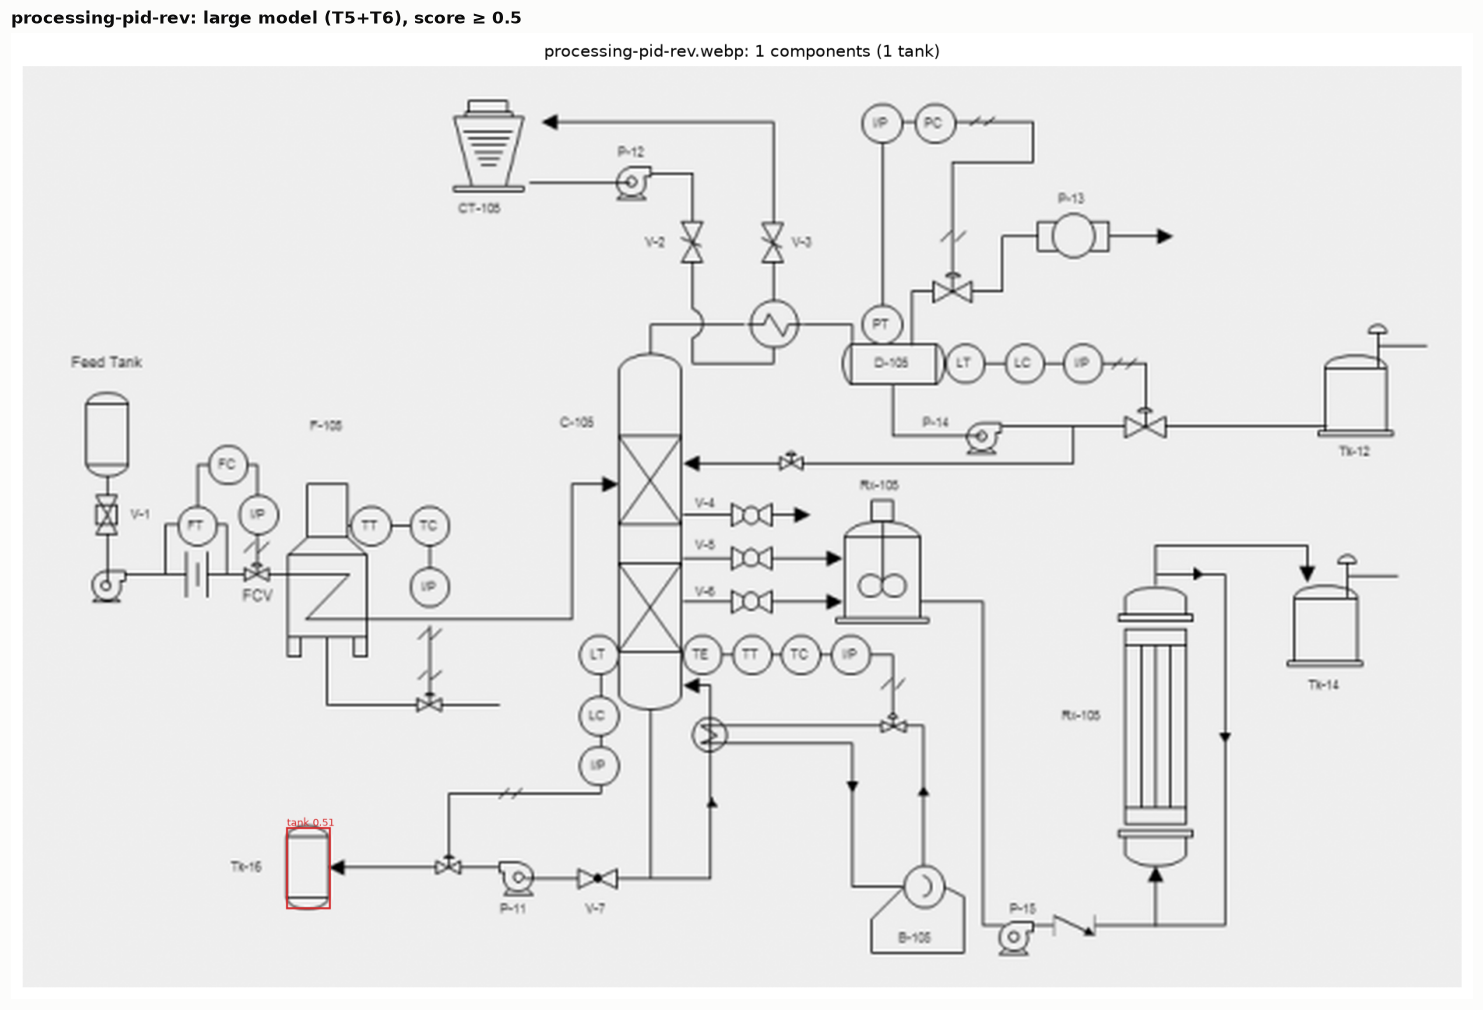

In [20]:
for name, _, _, png, _ in BIG_SHEETS:
    img = Image.open(png).convert("RGB")
    fig, ax = plt.subplots(figsize=(14, 14 * img.height / img.width))
    ax.imshow(img)
    ax.set_title(f"{name}: large model (T5+T6), score ≥ 0.5")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

### Findings: large model on outside drawings

Verdicts are visual judgements (no ground truth).

- **`M311…webp` (ethanol PFD, 2716×1616, clean drawing): good.** Finds most major items: 3 process tanks, rectification vessels, dryer, evaporator, mill, mixer. Misses the distillation column, labels the pump as `equipment` (0.53), and double-boxes the fermentation unit.
- **`piping-diagram-2` (942×792): mixed.** Finds the evaporator and the knockout drum (the drum gets duplicate boxes). Calls 7 instrument bubbles `tank`: large circles look like tank heads, and instruments are not among this model's classes. Misses the compressor.
- **`process-flow-diagram-osha-small` (241×312, tiny): mixed.** Finds the reactor, solvent stripper, wash vessel, vacuum receiver, reflux condenser and drum. Misses the 3 house-shaped storage tanks and the exchanger.
- **`processing-pid-rev` (650×416, grey background, low-res): poor.** Finds only Tk-16 and misses about 10 items (column, reactors, tanks, pumps, cooling tower).
- **`pid_big.png` (1232×720): poor.** Finds only condenser 13E02 (as `tank`). 6 of the 7 `equipment` boxes are the data tables in the bottom right. Misses the column, reactor, vessel, pumps and exchangers.

**Takeaways**
- The model works on **clean, reasonably sharp drawings**. It fails on **low-res or grey-background images** and on **symbol styles it has not seen** (house-shaped storage tanks).
- **Data tables and instrument bubbles cause false alarms.** Neither is a class here, so the model forces them into `equipment` or `tank`.
- Fixes, in order:
  1. **Higher-resolution input** (original PDFs/vector exports rather than screenshots).
  2. **Train the second (small-symbol) model and merge**, so instruments are claimed by it instead of showing up as `tank`.
  3. **Label real sheets (T7)** in the styles that fail here: house-shaped tanks, columns, compressors, grey low-res scans.

These are seed-0 results on 5 images, so treat them as qualitative evidence. The quantitative 3-seed numbers (on the 12 real sheets with ground truth) are in section 0.

### Optional input cleanup: original vs. cleaned

`clean_input()` in `nrp/train.py` is an **opt-in** step (`draw_prediction(..., clean=True)`, CLI `--predict-clean`; off by default, never used in training). It divides the image by its median grey level (grey background → white), resizes to long side 2048 px (LANCZOS), and binarizes (< 140 → black, else white). Box coordinates in the CSV are still in the **original** image's pixels. The idea: the model was trained on clean white sheets, so a grey, soft screenshot is out of distribution.

Same model (`runs/scr-t5t6-s0/best.pt`), same threshold (score ≥ 0.5), the only change is the cleanup. The cleaned predictions are in `out/test_pngs_clean/`. There is no ground truth, so the correct / false-alarm counts below are my **visual counts** from the images, not a metric.

In [21]:
CLEAN_DIR = OUT / "test_pngs_clean"
def clean_paths(src_img):
    return CLEAN_DIR / f"{Path(src_img).stem}_pred_t5t6_clean.csv", CLEAN_DIR / f"{Path(src_img).stem}_pred_t5t6_clean.png"

# hand counts from looking at each image pair (no ground truth):
#   correct = distinct major items covered by a box; extra = boxes that are duplicates or sit on non-equipment
VISUAL = {  # name: ((correct, extra) original, (correct, extra) cleaned, verdict)
    "pid_big.png": ((1, 7), (1, 3),
        "Neutral: still 1 item found, but a different one (13E02 condenser before, 13E01 preheater after). The 6 data-table boxes vanish (the tables turn into dots); 3 junk boxes remain (a blank region, two line-number labels)."),
    f"{M311[:4]}... (ethanol PFD)": ((12, 3), (11, 2),
        "Slightly worse: fermentation unit shrinks to its inner circle and the pump box is lost; milling gets a duplicate box. Clean input did not need cleaning."),
    "piping-diagram-2": ((2, 12), (2, 12),
        "No change: evaporator and drum found, 7-8 instrument bubbles still called tank; now also 2 arrowheads called equipment, the TIR box is gone."),
    "process-flow-diagram-osha-small": ((6, 0), (0, 0),
        "Hurts badly: 6 of 6 found before, nothing after. The 241x312 image is upscaled 8x; thresholding the blurry strokes breaks the outlines into dots and fragments."),
    "processing-pid-rev": ((1, 0), (5, 1),
        "Helps: feed tank, Tk-16, column C-105, drum D-105 and the tall Rx-105 found; 1 instrument bubble (FC) called tank. Still missing both Tk-12/Tk-14, the other reactor, the cooling tower, pumps."),
}
rows = []
for name, src_img, csv, _, _ in BIG_SHEETS:
    ccsv, _ = clean_paths(src_img)
    d0, d1 = pd.read_csv(csv), pd.read_csv(ccsv)
    assert (d1.score >= 0.5).all(), name
    w, h = Image.open(src_img).size
    assert (d1.xmax <= w * 1.01).all() and (d1.ymax <= h * 1.01).all() and (d1.xmin >= -1).all()  # CSV boxes are in original-image pixels (an empty CSV passes)
    n0 = d0.cls.value_counts().reindex(BIG_CLASSES, fill_value=0); n1 = d1.cls.value_counts().reindex(BIG_CLASSES, fill_value=0)
    (c0_, e0), (c1_, e1), verdict = VISUAL[name]
    rows.append({"image": name,
                 ("boxes: original", "tank"): n0["tank"], ("boxes: original", "pump"): n0["pump"], ("boxes: original", "equipment"): n0["equipment"], ("boxes: original", "total"): len(d0),
                 ("boxes: cleaned", "tank"): n1["tank"], ("boxes: cleaned", "pump"): n1["pump"], ("boxes: cleaned", "equipment"): n1["equipment"], ("boxes: cleaned", "total"): len(d1),
                 ("visual count", "correct: orig → clean"): f"{c0_} → {c1_}", ("visual count", "extra boxes: orig → clean"): f"{e0} → {e1}",
                 ("visual count", "verdict"): verdict})
    assert c0_ + e0 == len(d0) and c1_ + e1 == len(d1), (name, c0_, e0, len(d0), c1_, e1, len(d1))  # counts add up to the boxes in the CSVs
clean_cmp = pd.DataFrame(rows).set_index("image")
clean_cmp.columns = pd.MultiIndex.from_tuples(clean_cmp.columns)
tot = lambda i: sum(v[i][0] for v in VISUAL.values())
print(f"visual total correct: original {tot(0)} -> cleaned {tot(1)} (over 5 drawings)")
clean_cmp.style.set_properties(subset=[("visual count", "verdict")], **{"text-align": "left", "white-space": "normal", "min-width": "380px"})

visual total correct: original 22 -> cleaned 19 (over 5 drawings)


### Side by side: original (left) and cleaned (right)

Boxes are drawn on the image the model saw: the original greyscale on the left, the binarized version on the right.

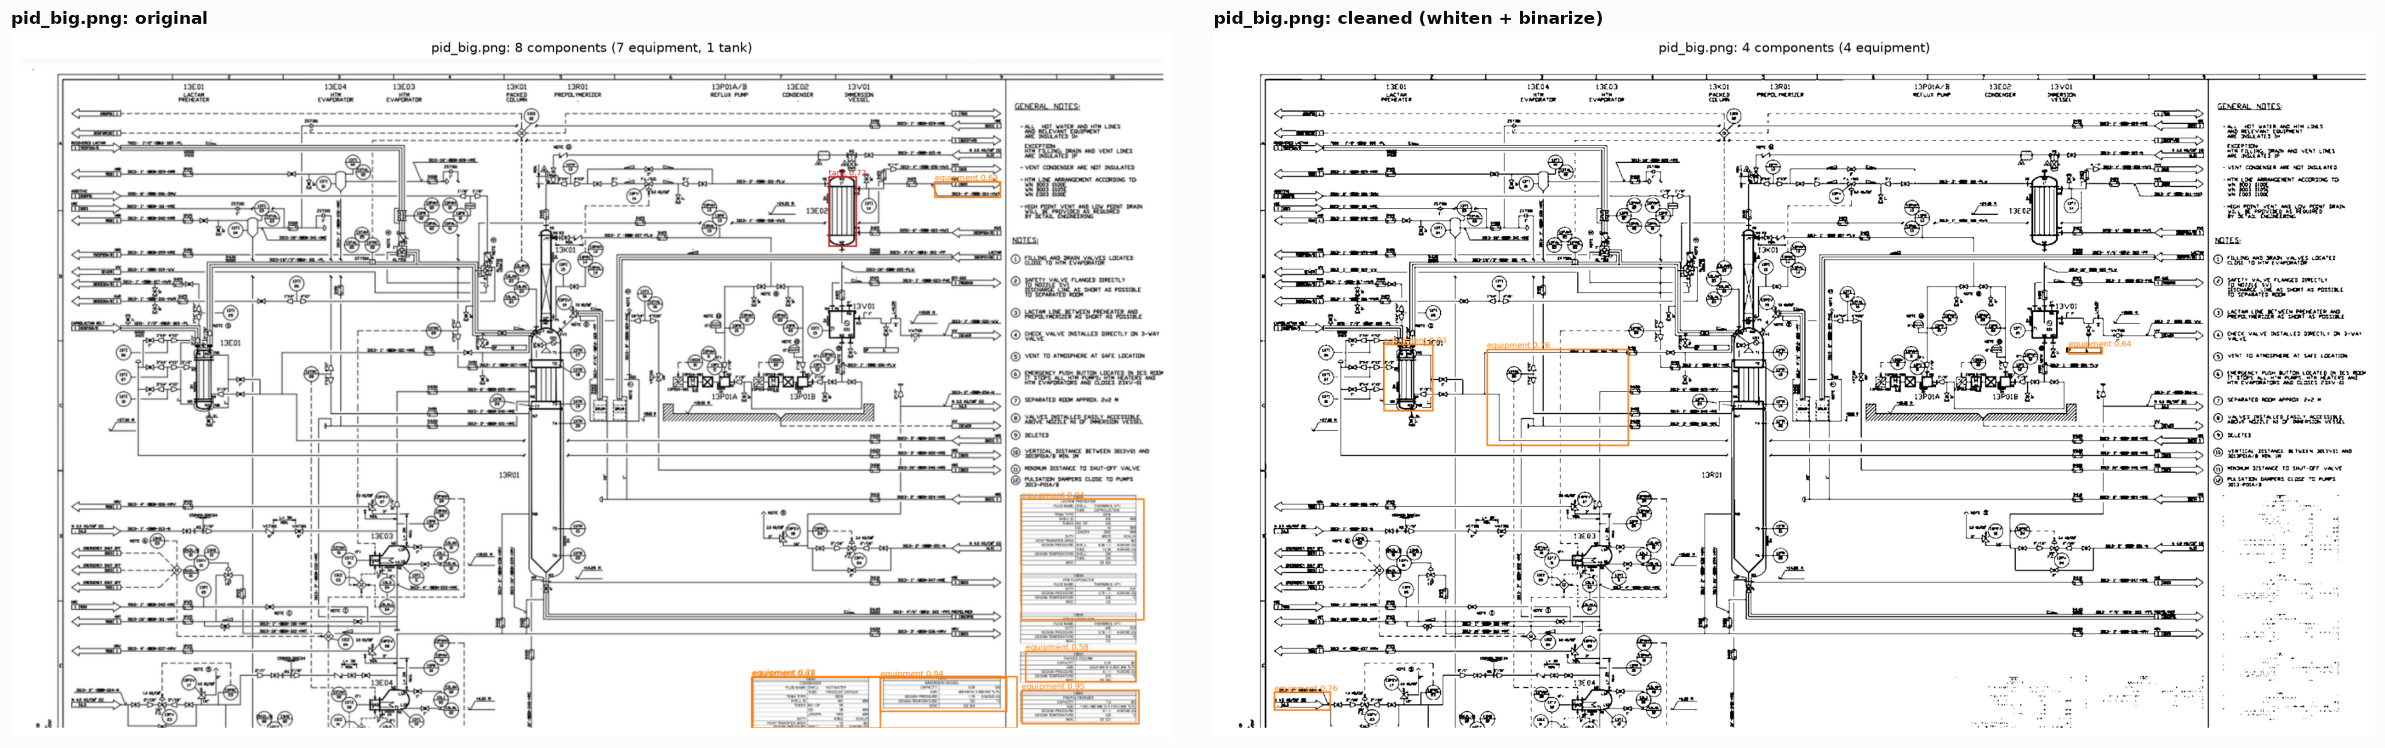

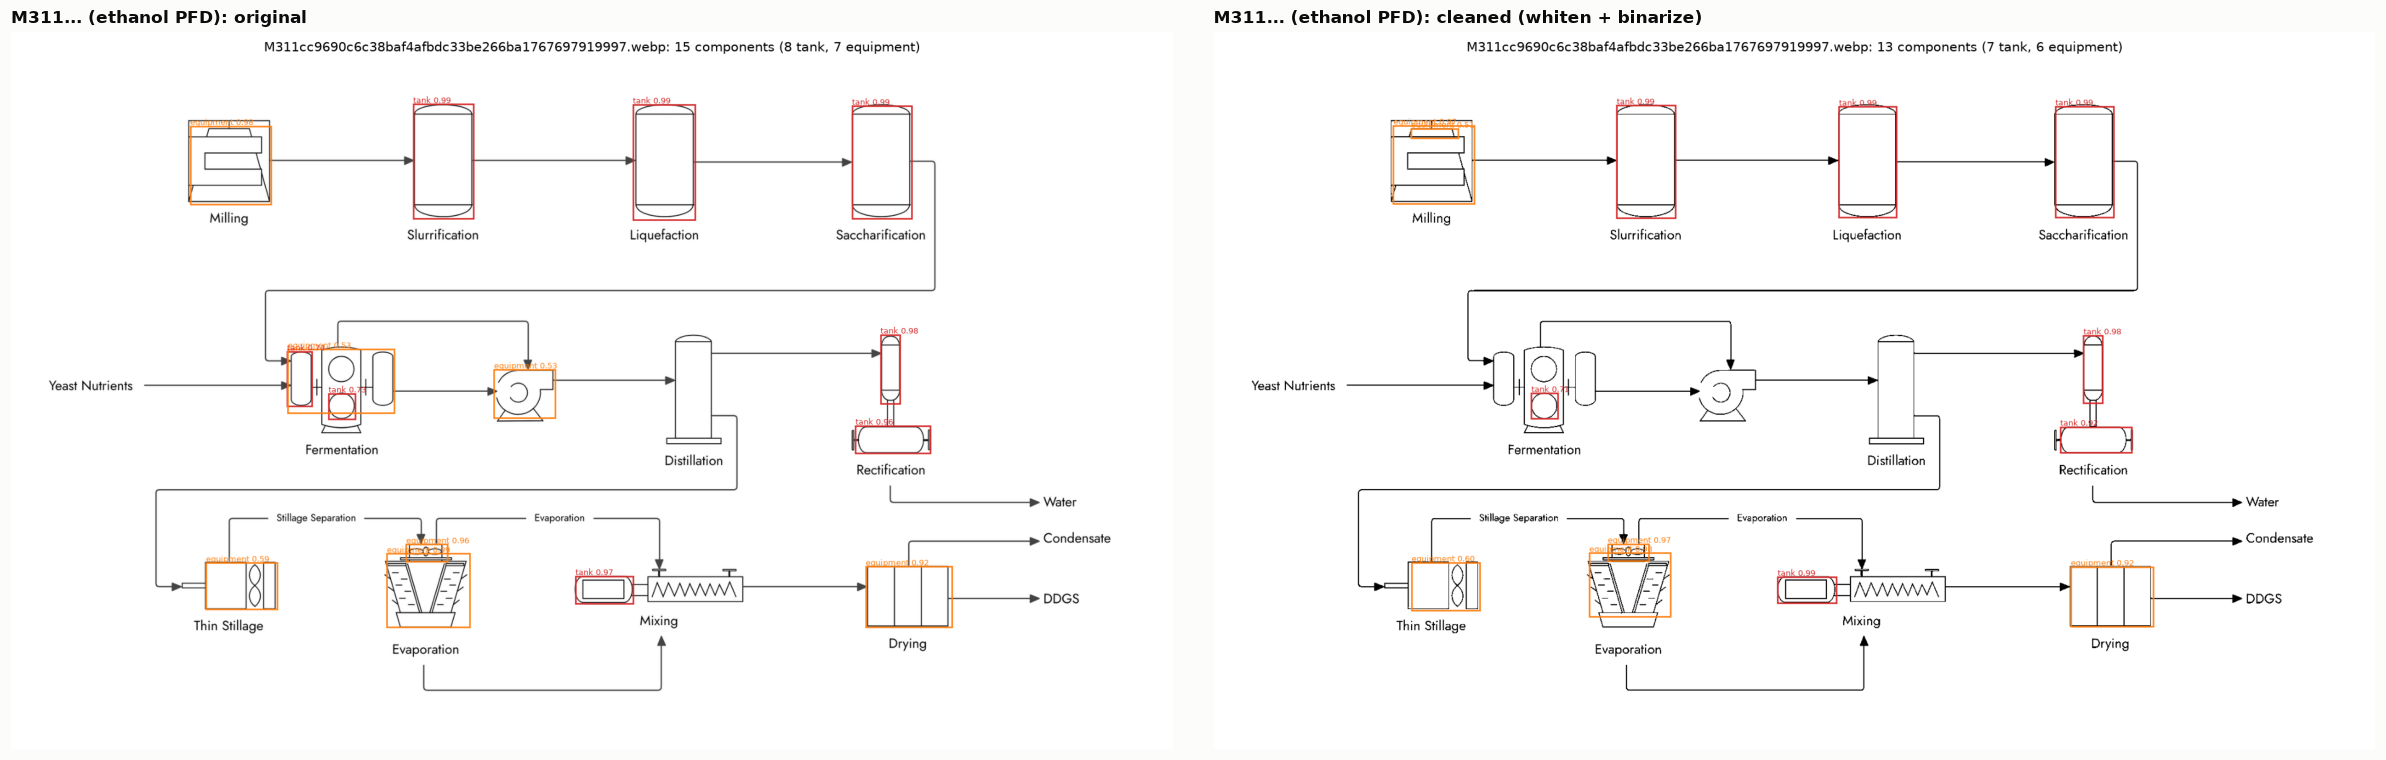

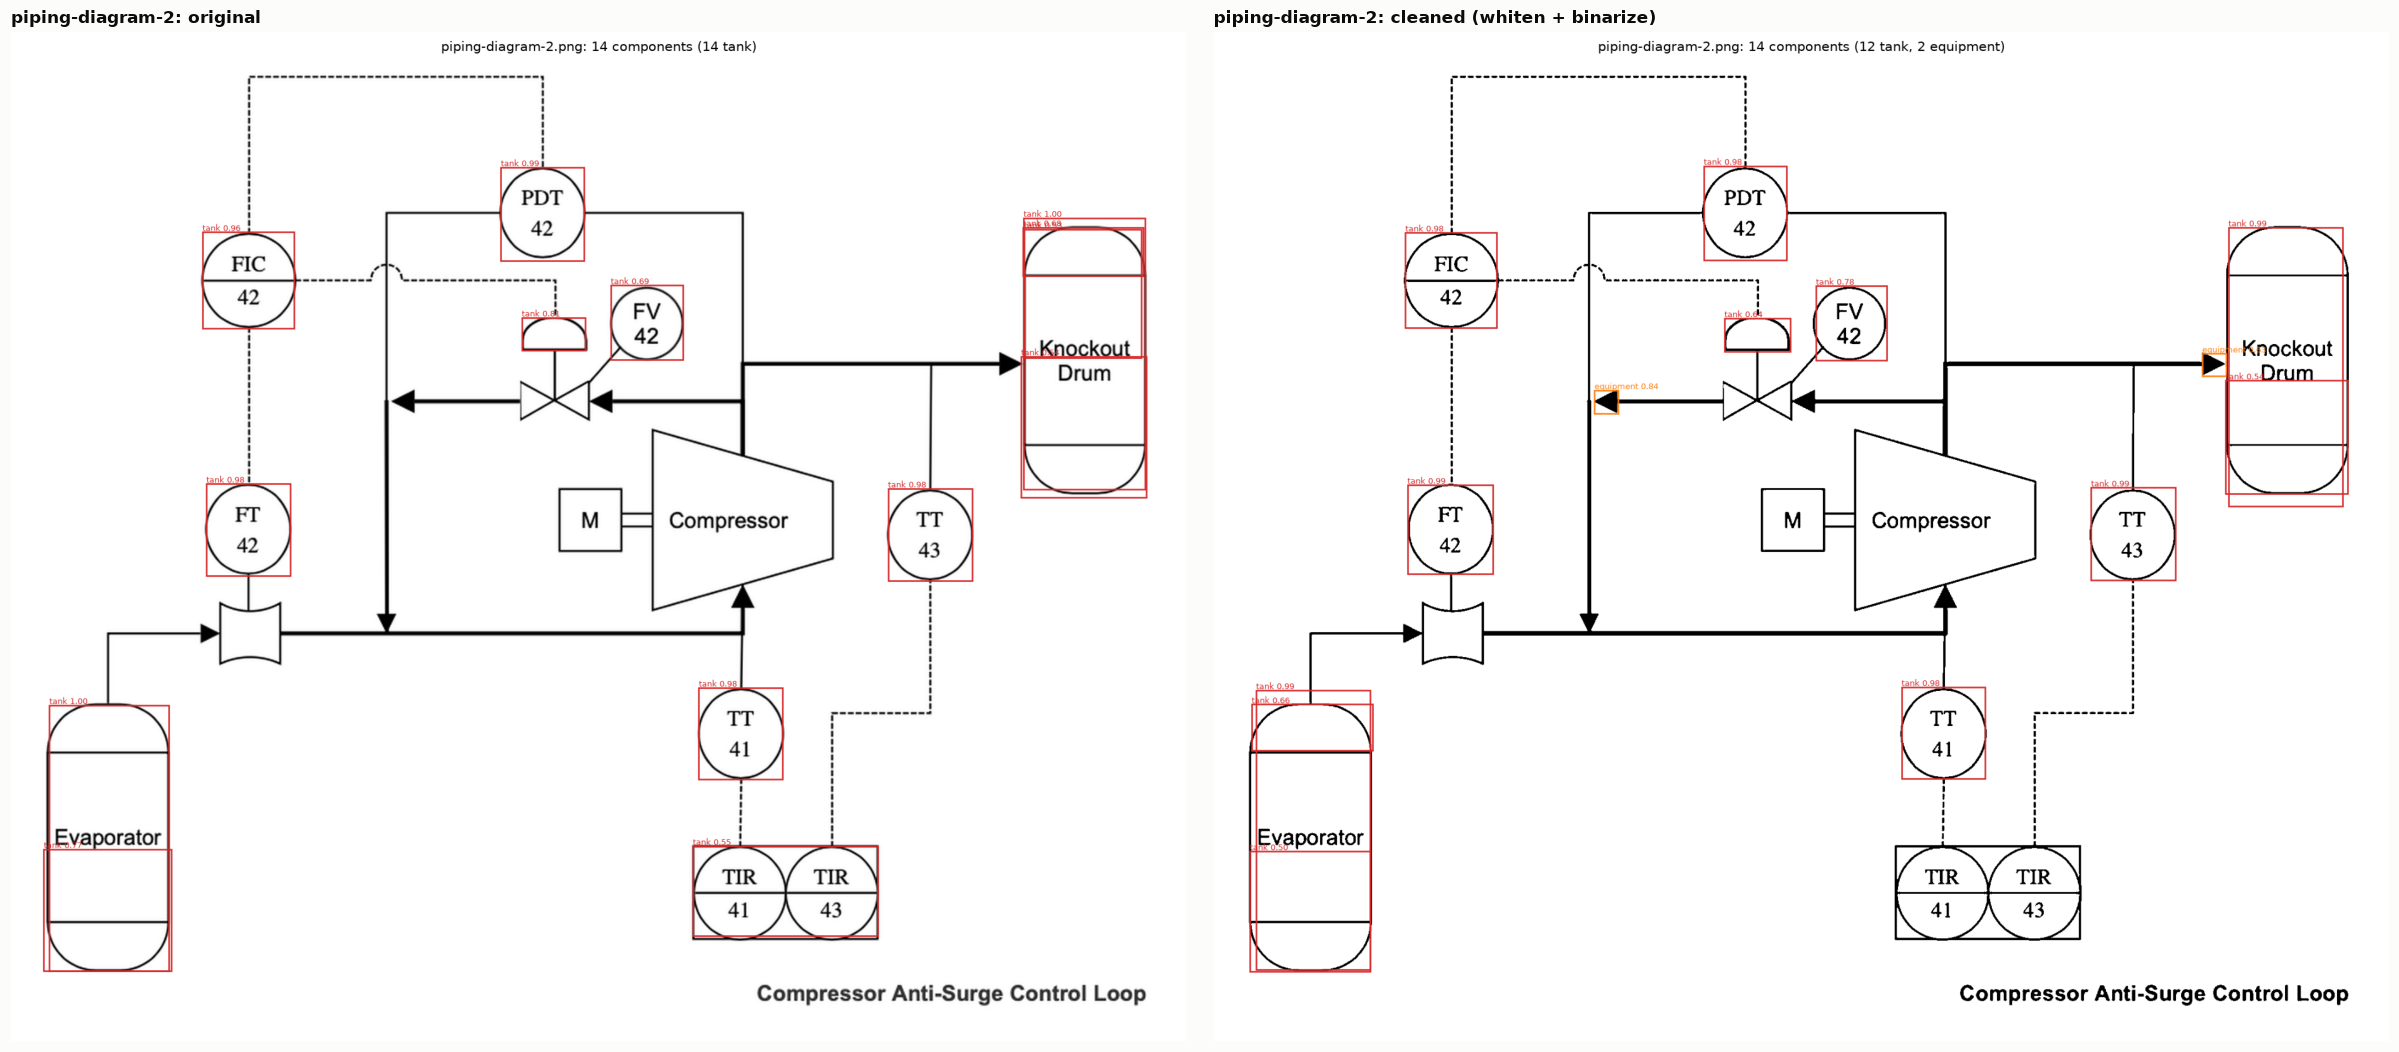

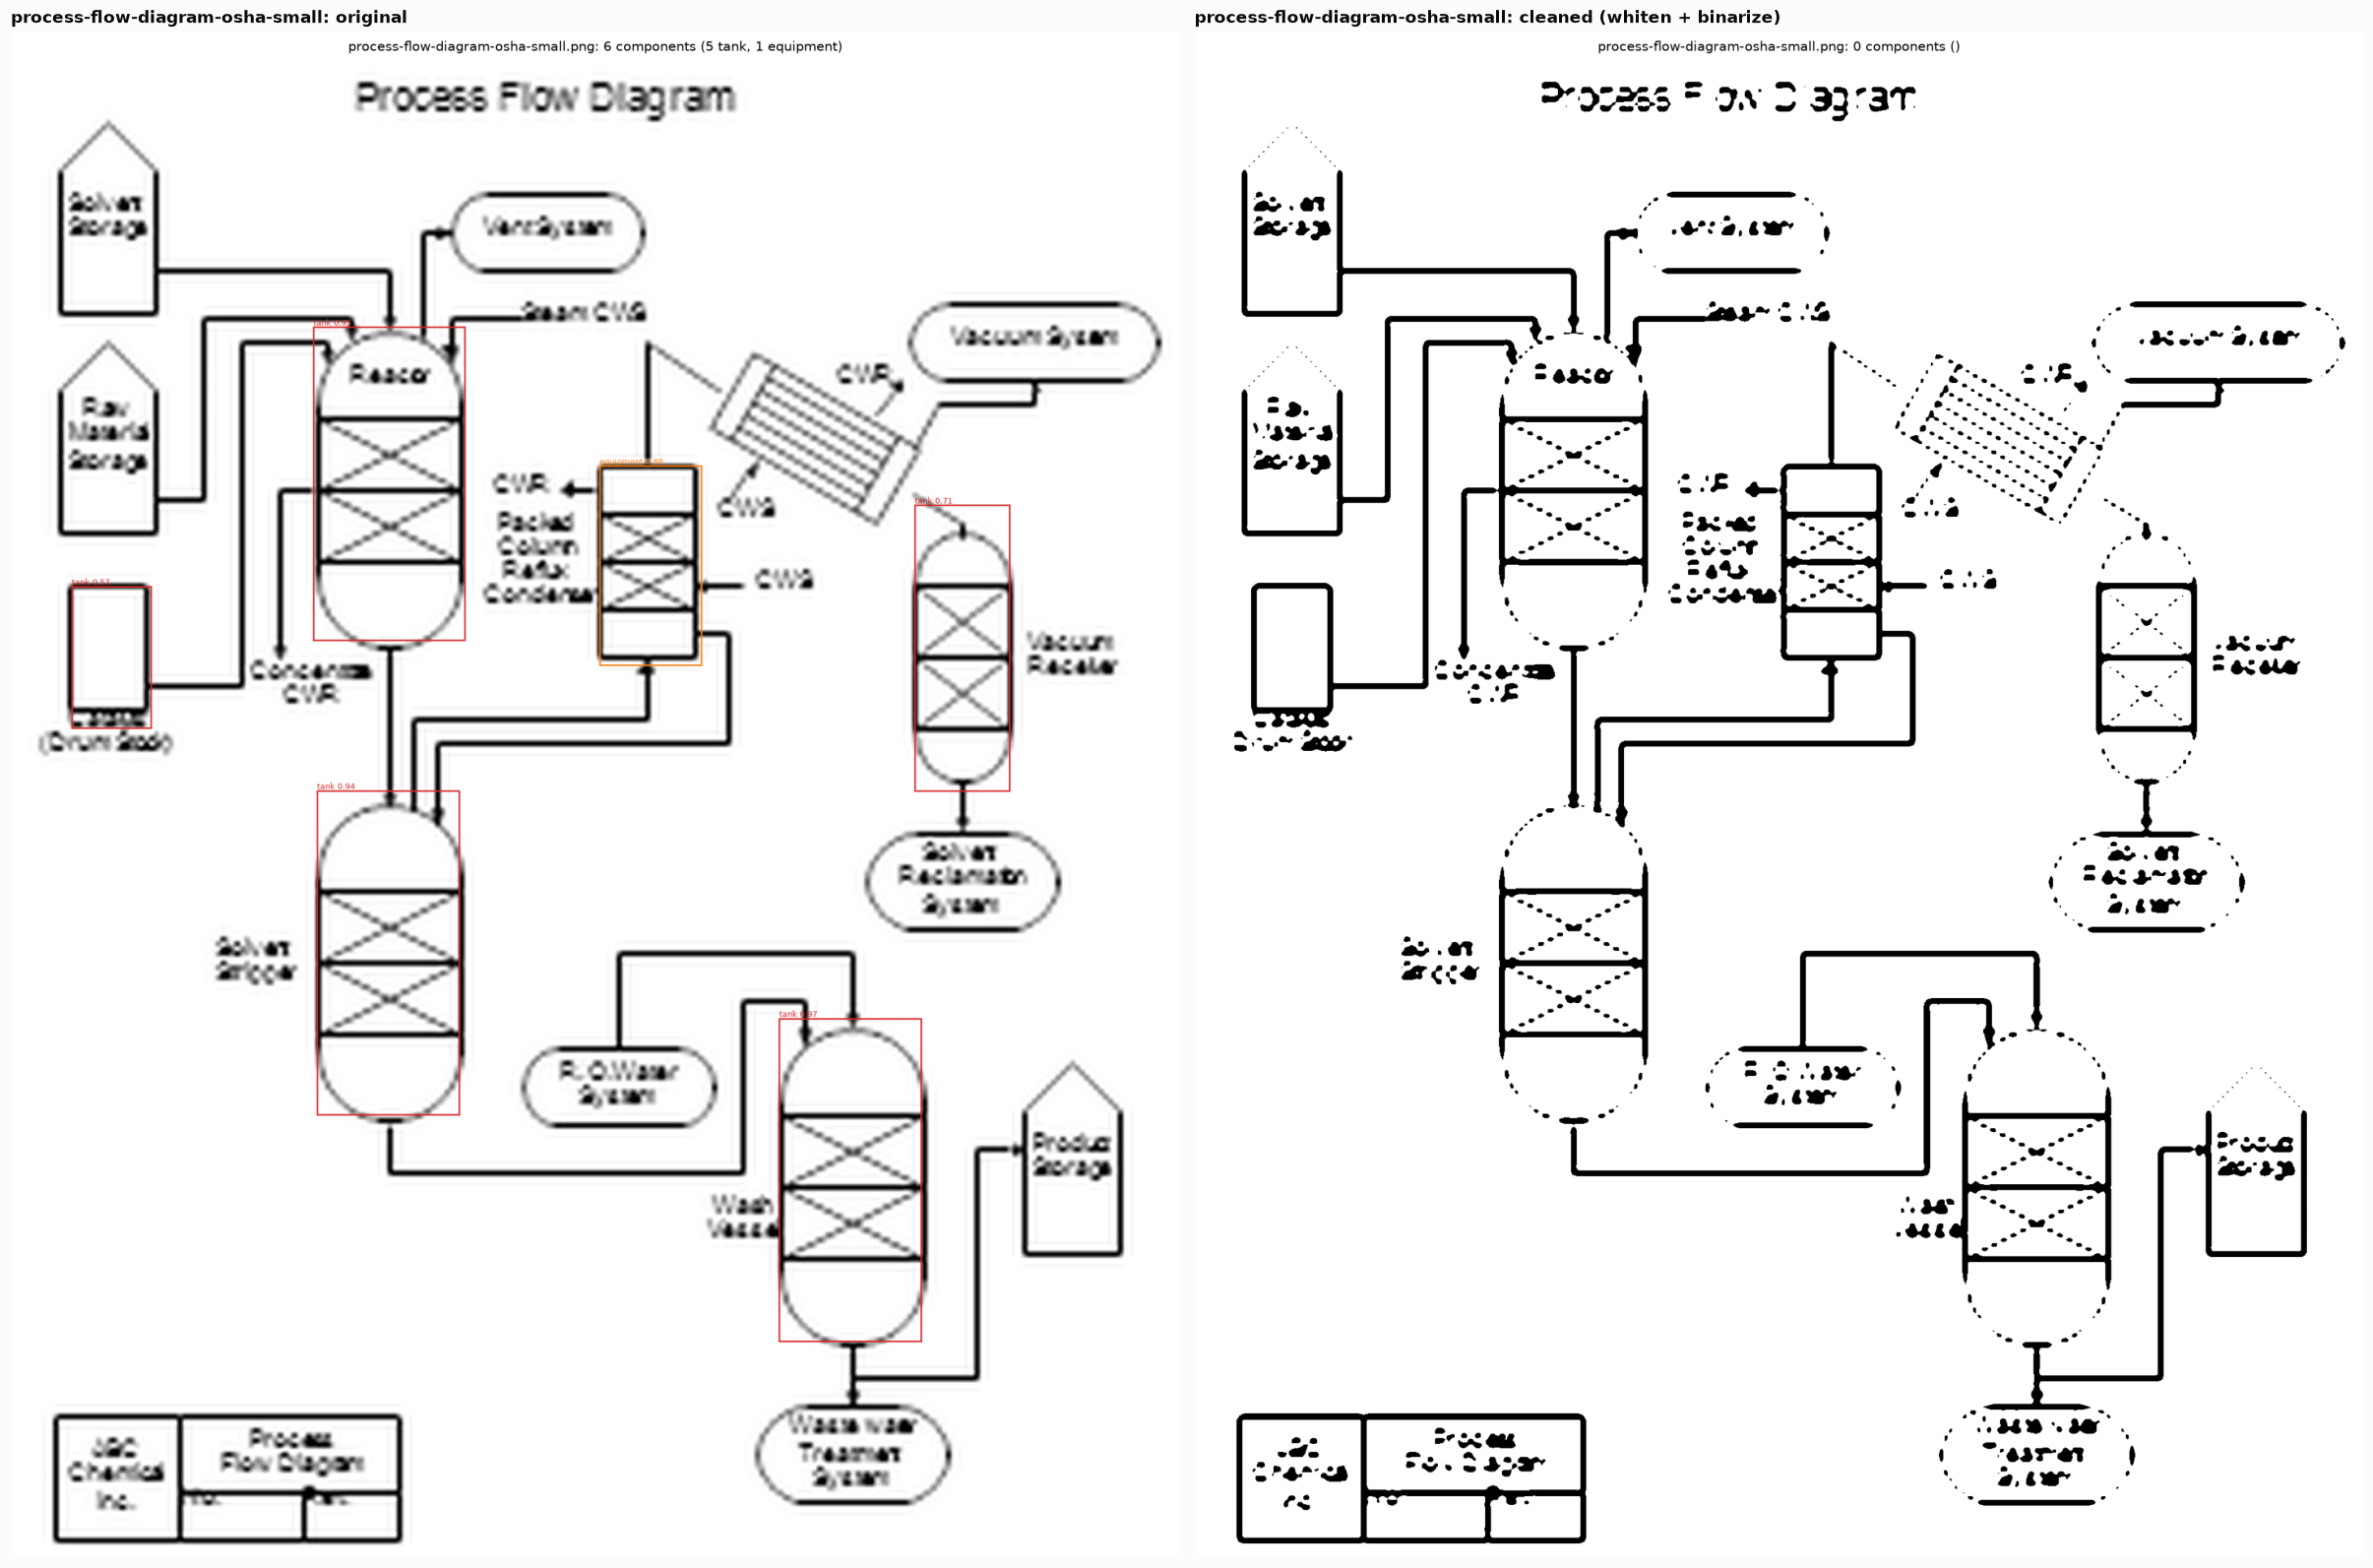

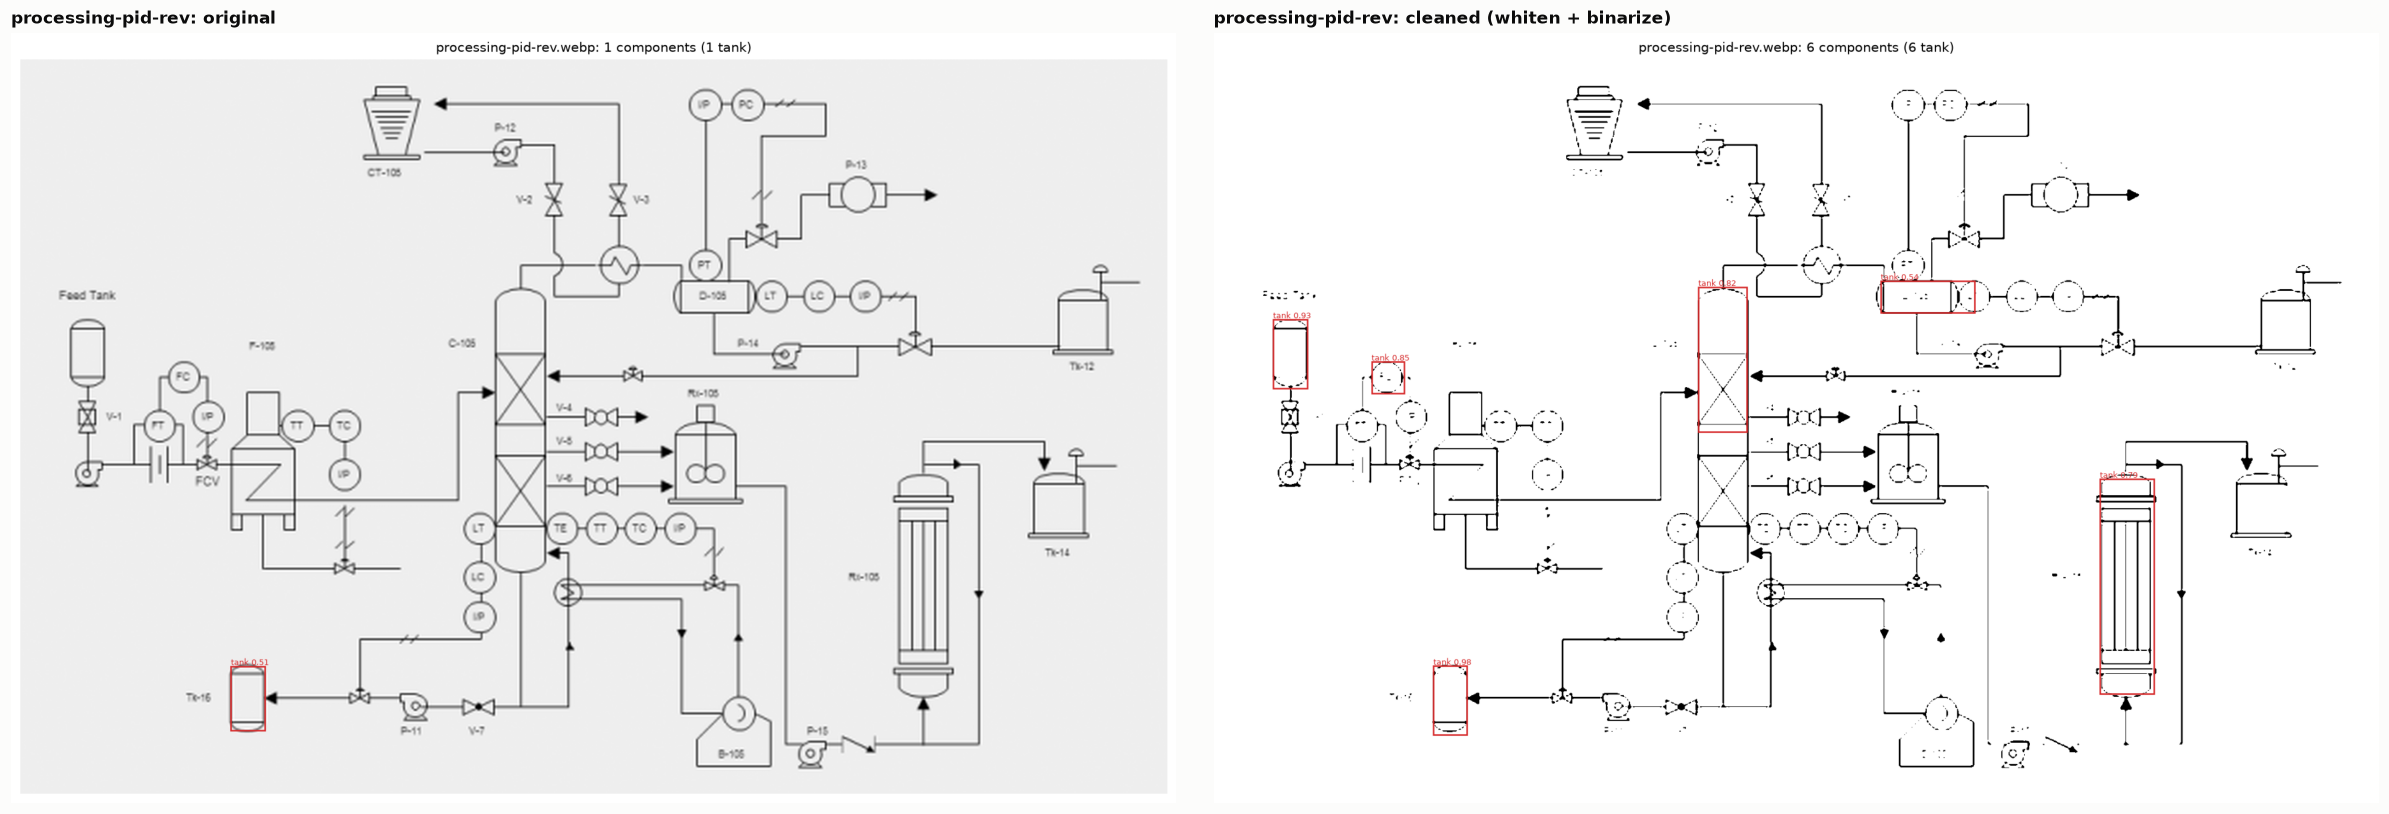

In [22]:
for name, src_img, _, png, _ in BIG_SHEETS:
    _, cpng = clean_paths(src_img)
    a_img, b_img = Image.open(png).convert("RGB"), Image.open(cpng).convert("RGB")
    fig, axs = plt.subplots(1, 2, figsize=(22, 11 * a_img.height / a_img.width))
    axs[0].imshow(a_img); axs[0].set_title(f"{name}: original")
    axs[1].imshow(b_img); axs[1].set_title(f"{name}: cleaned (whiten + binarize)")
    for a in axs: a.axis("off")
    plt.tight_layout(); plt.show()

### Findings: does the cleanup help?

Visual verdicts, one run (seed 0), 5 drawings, no ground truth. **Short answer: no, not as a default.** It helps one drawing a lot, hurts one completely, and is neutral or slightly negative on the other three. Summed over the 5 drawings: **22 correct items before, 19 after**.

- **`processing-pid-rev` (650×416, grey background, soft): 1 → 5 correct, 1 false alarm.** The one clear win: feed tank, Tk-16, column C-105, drum D-105 and the tall Rx-105 are found. One instrument bubble is called `tank`. (My hand run earlier also boxed a flow meter; this run did not, so the false-alarm count here is 1, not 2.)
- **`M311…webp` (ethanol PFD, clean): 12 → 11 correct.** It was already a clean white drawing, so there was nothing to fix; the fermentation unit is reduced to its inner circle, the pump box is lost, and the milling unit is boxed twice.
- **`piping-diagram-2`: 2 → 2 correct.** Same two items; the instrument bubbles are still called `tank`, and two arrowheads are now called `equipment`.
- **`process-flow-diagram-osha-small` (241×312): 6 → 0 correct. Cleaning hurts here.** The image is tiny and already blurry; upscaling it about 8× and then thresholding turns the soft strokes into dotted, broken outlines and the model finds nothing. (This is my explanation from the picture; I did not test other thresholds.)
- **`pid_big.png`: 1 → 1 correct.** A different item is found (13E01 instead of 13E02). The data tables are no longer boxed (6 false alarms gone), but 3 junk boxes remain. Still poor.

**Takeaways**
- Cleanup helps when the image has a **grey background and is otherwise sharp enough**. It hurts on **very low-resolution** images, where binarizing destroys thin lines.
- It does not fix the real problems: instrument bubbles called `tank`, and unseen symbol styles.
- Keep it **off by default**. Try it only on grey-background screenshots, and compare with the original output before trusting it. Whitening alone, a threshold of 200, or skipping the binarization are untested variants worth trying on a labelled set of real screenshots; this evidence is 5 unlabelled drawings.